# Credit Risk Scoring System

### Project Overview

This project develops a machine learning-based credit scoring model to predict an individual's creditworthiness using historical financial and credit-related data.

The project covers data cleaning, exploratory data analysis, feature engineering from historical credit sources, model development and comparison, threshold selection, explainability with SHAP, and packaging the final model so it can be reused outside the notebook.


### Objective

The objective of this project is to predict an individual's creditworthiness using past financial and credit-related data.

Classification algorithms such as Logistic Regression, Decision Tree, and Random Forest are used to develop and evaluate the credit risk scoring model. Because the target is highly imbalanced, the models are compared using imbalance-aware metrics rather than accuracy.


## 1. Dataset and Data Source

### Dataset Description

This project uses the **Home Credit Default Risk** dataset, which contains financial and credit-related information about loan applicants.

The dataset includes applicant demographic information, financial information, credit history, previous applications, and other relevant attributes.

### Data Source

The dataset was obtained from the **Home Credit Default Risk** competition on Kaggle.

This project uses four files from that dataset:

- **application_train.csv** — the main applicant/application file. It contains applicant information and the `TARGET` column, and forms the base of the dataset.
- **bureau.csv** — previous credit history reported by other financial institutions.
- **previous_application.csv** — the applicant's previous loan/application history with Home Credit.
- **installments_payments.csv** — historical installment repayment records, showing how applicants paid past loans.

`application_train.csv` is the main file. The other three files are historical/behavioral sources, used to create additional features at the applicant level (explained in the Feature Engineering sections below).

Other files provided in the same Kaggle dataset (`bureau_balance.csv`, `POS_CASH_balance.csv`, `credit_card_balance.csv`) were not used in this project. This is discussed further in the Limitations section.


## 2. Dataset Loading

### Loading the Training Dataset

The training dataset is loaded using Pandas.

The training data contains the target variable `TARGET`, which indicates whether an applicant experienced loan repayment difficulties.

The raw dataset is kept unchanged so that the original data remains available for reference.


In [114]:
from pathlib import Path

# The project root is found by walking up from the current working directory
# until the "data" folder is found. This keeps the notebook working whether it
# is opened from the project root or from the notebook/ folder.
def find_project_root(start: Path) -> Path:
    for folder in [start] + list(start.parents):
        if (folder / "data").exists():
            return folder
    return start

PROJECT_ROOT = find_project_root(Path.cwd().resolve())

RAW_DATA = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"

for folder in [PROCESSED_DATA, MODELS_DIR, REPORTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)


Project root: C:\Credit-Risk-Scoring-System


In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

train_path = RAW_DATA / "application_train.csv"
df = pd.read_csv(train_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()


Dataset loaded successfully!
Shape: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Dataset Overview

### Understanding the Dataset Structure

Before performing data preprocessing, the dataset is inspected to understand its size, columns, data types, and overall structure.

This initial inspection helps identify numerical and categorical variables and provides a better understanding of the available financial and credit-related information.


In [116]:
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()


Dataset Shape: (307511, 122)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB


## 4. Target Variable Analysis

### Understanding the Target Variable

The target variable `TARGET` represents the credit outcome of each applicant.

- `TARGET = 0`: Applicant did not experience loan repayment difficulties.
- `TARGET = 1`: Applicant experienced loan repayment difficulties.

The distribution of the target classes is analyzed to determine whether the dataset is balanced or imbalanced.


In [117]:
print(df["TARGET"].value_counts())

print("\nTarget Percentage:")
print(df["TARGET"].value_counts(normalize=True) * 100)


TARGET
0    282686
1     24825
Name: count, dtype: int64

Target Percentage:
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


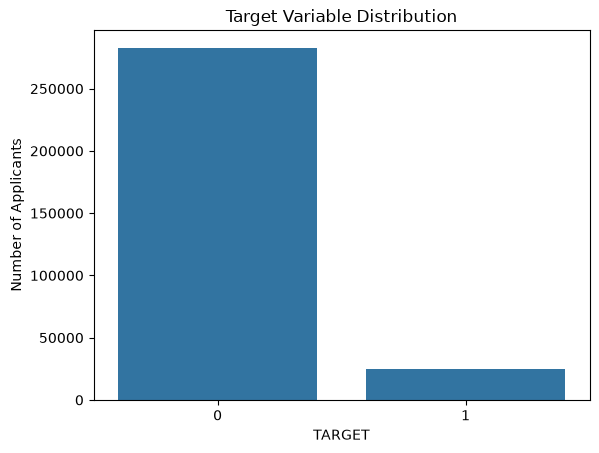

In [118]:
sns.countplot(x="TARGET", data=df)

plt.title("Target Variable Distribution")
plt.xlabel("TARGET")
plt.ylabel("Number of Applicants")
plt.show()


## 5. Missing Value Analysis

### Identifying Missing Data

Missing values are examined across all features to understand the quality and completeness of the dataset.

Instead of immediately filling or deleting missing values, the missing-value pattern is first analyzed. This helps determine an appropriate preprocessing strategy for the machine learning models.


In [119]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing.head(20)


COMMONAREA_MEDI             214865
COMMONAREA_MODE             214865
COMMONAREA_AVG              214865
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_MEDI    213514
NONLIVINGAPARTMENTS_AVG     213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_AVG        210199
LIVINGAPARTMENTS_MEDI       210199
LIVINGAPARTMENTS_MODE       210199
FLOORSMIN_MEDI              208642
FLOORSMIN_MODE              208642
FLOORSMIN_AVG               208642
YEARS_BUILD_MODE            204488
YEARS_BUILD_MEDI            204488
YEARS_BUILD_AVG             204488
OWN_CAR_AGE                 202929
LANDAREA_AVG                182590
LANDAREA_MEDI               182590
LANDAREA_MODE               182590
dtype: int64

In [120]:
print("Total columns:", df.shape[1])
print("Columns with missing values:", df.isnull().any().sum())


Total columns: 122
Columns with missing values: 67


## 6. Data Quality Checks

### Checking Data Quality

Before performing data cleaning and preprocessing, basic data quality checks are performed.

This includes checking for duplicate rows, duplicate applicant IDs, unexpected target values, and features with very few unique values.

These checks help ensure that the dataset is reliable and suitable for further analysis.


In [121]:
print("Duplicate rows:", df.duplicated().sum())

print("Duplicate applicant IDs:", df["SK_ID_CURR"].duplicated().sum())

print("Unique TARGET values:", df["TARGET"].unique())


Duplicate rows: 0
Duplicate applicant IDs: 0
Unique TARGET values: [1 0]


In [122]:
df.nunique().sort_values().head(20)


TARGET                         2
NAME_CONTRACT_TYPE             2
FLAG_OWN_REALTY                2
FLAG_OWN_CAR                   2
FLAG_WORK_PHONE                2
FLAG_CONT_MOBILE               2
FLAG_EMP_PHONE                 2
FLAG_MOBIL                     2
FLAG_PHONE                     2
FLAG_EMAIL                     2
LIVE_CITY_NOT_WORK_CITY        2
REG_CITY_NOT_WORK_CITY         2
LIVE_REGION_NOT_WORK_REGION    2
REG_CITY_NOT_LIVE_CITY         2
REG_REGION_NOT_LIVE_REGION     2
REG_REGION_NOT_WORK_REGION     2
FLAG_DOCUMENT_18               2
FLAG_DOCUMENT_19               2
FLAG_DOCUMENT_20               2
FLAG_DOCUMENT_21               2
dtype: int64

## 7. Data Cleaning

### Preparing the Dataset

The dataset is cleaned based on the results of the previous data quality and missing-value analysis.

Irrelevant or unsuitable features are identified, while missing values and categorical variables are handled using appropriate preprocessing techniques.

The original raw dataset is preserved, and cleaning is performed on a separate working dataset.


In [123]:
missing_info = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": (df.isnull().sum() / len(df)) * 100
})

missing_info = missing_info.sort_values(
    by="missing_percentage",
    ascending=False
)

print("More than 50% missing:",
      (missing_info["missing_percentage"] > 50).sum())

print("More than 30% missing:",
      (missing_info["missing_percentage"] > 30).sum())

print("More than 10% missing:",
      (missing_info["missing_percentage"] > 10).sum())

print("Less than or equal to 10% missing:",
      (missing_info["missing_percentage"] <= 10).sum())


More than 50% missing: 41
More than 30% missing: 50
More than 10% missing: 57
Less than or equal to 10% missing: 65


In [124]:
# Create a working copy for data cleaning
df_clean = df.copy()

print("Working dataset created successfully!")
print("Shape:", df_clean.shape)


Working dataset created successfully!
Shape: (307511, 122)


In [125]:
# Display columns with more than 50% missing values

high_missing_cols = missing_info[
    missing_info["missing_percentage"] > 50
]

print("Number of columns with more than 50% missing:",
      len(high_missing_cols))

display(high_missing_cols)


Number of columns with more than 50% missing: 41


,missing_count,missing_percentage
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


In [126]:
# Analyze unique values of high-missing columns

high_missing_analysis = pd.DataFrame({
    "missing_count": df_clean[high_missing_cols.index].isnull().sum(),
    "missing_percentage": df_clean[high_missing_cols.index].isnull().mean() * 100,
    "unique_values": df_clean[high_missing_cols.index].nunique()
})

high_missing_analysis = high_missing_analysis.sort_values(
    by="missing_percentage",
    ascending=False
)

display(high_missing_analysis)


,missing_count,missing_percentage,unique_values
COMMONAREA_AVG,214865,69.872297,3181
COMMONAREA_MODE,214865,69.872297,3128
COMMONAREA_MEDI,214865,69.872297,3202
NONLIVINGAPARTMENTS_MEDI,213514,69.432963,214
NONLIVINGAPARTMENTS_MODE,213514,69.432963,167
NONLIVINGAPARTMENTS_AVG,213514,69.432963,386
FONDKAPREMONT_MODE,210295,68.386172,4
LIVINGAPARTMENTS_AVG,210199,68.354953,1868
LIVINGAPARTMENTS_MEDI,210199,68.354953,1097
LIVINGAPARTMENTS_MODE,210199,68.354953,736


In [127]:
# Analyze important high-missing features

important_missing_cols = [
    "EXT_SOURCE_1",
    "OWN_CAR_AGE"
]

important_analysis = df_clean[
    important_missing_cols + ["TARGET"]
].describe(include="all").T

display(important_analysis)


,count,mean,std,min,25%,50%,75%,max
EXT_SOURCE_1,134133.0,0.502130,0.211062,0.014568,0.334007,0.505998,0.675053,0.962693
OWN_CAR_AGE,104582.0,12.061091,11.944812,0.000000,5.000000,9.000000,15.000000,91.000000
TARGET,307511.0,0.080729,0.272419,0.000000,0.000000,0.000000,0.000000,1.000000


In [128]:
# Check OWN_CAR_AGE missing values against car ownership

car_age_check = df_clean.groupby("FLAG_OWN_CAR")["OWN_CAR_AGE"].agg(
    total_records="count",
    missing_values=lambda x: x.isnull().sum(),
    mean_car_age="mean"
)

display(car_age_check)


,total_records,missing_values,mean_car_age
FLAG_OWN_CAR,,,
N,0,202924,NaN
Y,104582,5,12.061091


In [129]:
# Identify columns with very high missing values

high_missing_cols = missing_info[
    missing_info["missing_percentage"] > 60
].index.tolist()

print("Columns with more than 60% missing values:", len(high_missing_cols))
print("\nColumns:")
for col in high_missing_cols:
    print(col)


Columns with more than 60% missing values: 17

Columns:
COMMONAREA_AVG
COMMONAREA_MODE
COMMONAREA_MEDI
NONLIVINGAPARTMENTS_MEDI
NONLIVINGAPARTMENTS_MODE
NONLIVINGAPARTMENTS_AVG
FONDKAPREMONT_MODE
LIVINGAPARTMENTS_AVG
LIVINGAPARTMENTS_MEDI
LIVINGAPARTMENTS_MODE
FLOORSMIN_MODE
FLOORSMIN_AVG
FLOORSMIN_MEDI
YEARS_BUILD_AVG
YEARS_BUILD_MODE
YEARS_BUILD_MEDI
OWN_CAR_AGE


### Data Cleaning Decision

Features with more than 60% missing values were reviewed before removal. 
Most of these features were property-related variables with extremely high 
missingness and multiple statistical versions such as AVG, MODE, and MEDI. 
Keeping these sparse and redundant features could increase noise and model 
complexity.

Therefore, 16 highly-missing property-related features were removed.

However, OWN_CAR_AGE was retained because its missingness is strongly related 
to FLAG_OWN_CAR. Applicants who do not own a car naturally have no car-age 
information, while only a small number of car owners have missing values. 
Thus, the missingness itself carries meaningful information.


In [130]:
# Drop highly missing and less useful property-related features

cols_to_drop = [
    "COMMONAREA_AVG",
    "COMMONAREA_MODE",
    "COMMONAREA_MEDI",
    "NONLIVINGAPARTMENTS_MEDI",
    "NONLIVINGAPARTMENTS_MODE",
    "NONLIVINGAPARTMENTS_AVG",
    "FONDKAPREMONT_MODE",
    "LIVINGAPARTMENTS_AVG",
    "LIVINGAPARTMENTS_MEDI",
    "LIVINGAPARTMENTS_MODE",
    "FLOORSMIN_MODE",
    "FLOORSMIN_AVG",
    "FLOORSMIN_MEDI",
    "YEARS_BUILD_AVG",
    "YEARS_BUILD_MODE",
    "YEARS_BUILD_MEDI"
]

df_clean = df_clean.drop(columns=cols_to_drop)

print("Columns dropped:", len(cols_to_drop))
print("New dataset shape:", df_clean.shape)


Columns dropped: 16
New dataset shape: (307511, 106)


### Remaining Missing Values

After removing highly sparse and redundant features, the remaining missing values are analyzed to determine appropriate imputation strategies.

Numerical features will generally be handled using median imputation and categorical features using the most frequent category. These fills are applied later inside the preprocessing pipeline rather than here, so that the values are learned from the training data only.


In [131]:
# Analyze remaining missing values after column removal

remaining_missing = df_clean.isnull().sum()

remaining_missing = remaining_missing[
    remaining_missing > 0
].sort_values(ascending=False)

remaining_missing_info = pd.DataFrame({
    "missing_count": remaining_missing,
    "missing_percentage": (remaining_missing / len(df_clean)) * 100
})

print("Number of columns with missing values:",
      len(remaining_missing_info))

display(remaining_missing_info.head(30))


Number of columns with missing values: 51


,missing_count,missing_percentage
OWN_CAR_AGE,202929,65.990810
LANDAREA_AVG,182590,59.376738
LANDAREA_MODE,182590,59.376738
LANDAREA_MEDI,182590,59.376738
BASEMENTAREA_MEDI,179943,58.515956
BASEMENTAREA_MODE,179943,58.515956
BASEMENTAREA_AVG,179943,58.515956
EXT_SOURCE_1,173378,56.381073
NONLIVINGAREA_AVG,169682,55.179164
NONLIVINGAREA_MEDI,169682,55.179164


### Review of Remaining High-Missing Features

Some features still have more than 50% missing values after the first cleaning step.

These features are mainly related to property information. Before removing them, their usefulness and similarity with other features are considered. Important features such as `EXT_SOURCE_1` are kept for further analysis.


In [132]:
# Identify remaining features with more than 50% missing values

remaining_high_missing = remaining_missing_info[
    remaining_missing_info["missing_percentage"] > 50
]

print("Number of remaining columns with more than 50% missing:",
      len(remaining_high_missing))

display(remaining_high_missing)


Number of remaining columns with more than 50% missing: 25


,missing_count,missing_percentage
OWN_CAR_AGE,202929,65.990810
LANDAREA_AVG,182590,59.376738
LANDAREA_MODE,182590,59.376738
LANDAREA_MEDI,182590,59.376738
BASEMENTAREA_MEDI,179943,58.515956
BASEMENTAREA_MODE,179943,58.515956
BASEMENTAREA_AVG,179943,58.515956
EXT_SOURCE_1,173378,56.381073
NONLIVINGAREA_AVG,169682,55.179164
NONLIVINGAREA_MEDI,169682,55.179164


### Handling Remaining High-Missing Features

The remaining features with more than 50% missing values were reviewed.

Most of these features are related to property information and have multiple similar versions such as AVG, MEDI, and MODE. To reduce missing data and keep the dataset simple, these features were removed.

`EXT_SOURCE_1` was kept because it is a useful numerical feature for credit risk prediction. `OWN_CAR_AGE` was also kept because its missing values are mainly related to applicants who do not own a car.


In [133]:
# Drop remaining high-missing property features

cols_to_drop_remaining = [
    "LANDAREA_AVG",
    "LANDAREA_MODE",
    "LANDAREA_MEDI",
    "BASEMENTAREA_MEDI",
    "BASEMENTAREA_MODE",
    "BASEMENTAREA_AVG",
    "NONLIVINGAREA_AVG",
    "NONLIVINGAREA_MEDI",
    "NONLIVINGAREA_MODE",
    "ELEVATORS_MEDI",
    "ELEVATORS_MODE",
    "ELEVATORS_AVG",
    "WALLSMATERIAL_MODE",
    "APARTMENTS_AVG",
    "APARTMENTS_MODE",
    "APARTMENTS_MEDI",
    "ENTRANCES_AVG",
    "ENTRANCES_MEDI",
    "ENTRANCES_MODE",
    "LIVINGAREA_MODE",
    "LIVINGAREA_AVG",
    "LIVINGAREA_MEDI",
    "HOUSETYPE_MODE"
]

df_clean = df_clean.drop(columns=cols_to_drop_remaining)

print("Columns dropped:", len(cols_to_drop_remaining))
print("Current dataset shape:", df_clean.shape)


Columns dropped: 23
Current dataset shape: (307511, 83)


### Analysis of Remaining Missing Values

After removing highly sparse features, 28 columns still contain missing values.

These remaining features are reviewed based on their missing percentage and data type. This helps us choose suitable imputation methods without losing useful information.


In [134]:
remaining_missing = df_clean.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(
    ascending=False
)

remaining_missing_info = pd.DataFrame({
    "missing_count": remaining_missing,
    "missing_percentage": (remaining_missing / len(df_clean)) * 100,
    "data_type": df_clean[remaining_missing.index].dtypes.astype(str)
})

display(remaining_missing_info)


,missing_count,missing_percentage,data_type
OWN_CAR_AGE,202929,65.990810,float64
EXT_SOURCE_1,173378,56.381073,float64
FLOORSMAX_AVG,153020,49.760822,float64
FLOORSMAX_MODE,153020,49.760822,float64
FLOORSMAX_MEDI,153020,49.760822,float64
YEARS_BEGINEXPLUATATION_MEDI,150007,48.781019,float64
YEARS_BEGINEXPLUATATION_MODE,150007,48.781019,float64
YEARS_BEGINEXPLUATATION_AVG,150007,48.781019,float64
TOTALAREA_MODE,148431,48.268517,float64
EMERGENCYSTATE_MODE,145755,47.398304,str


### Handling Remaining High-Missing Features

The remaining features with close to 50% missing values were reviewed.

Most of these features are related to property information and have multiple similar versions such as AVG, MEDI, and MODE. To reduce missing data and keep the dataset simple, these highly sparse property-related features were removed.

Important features such as `EXT_SOURCE_1` and `OWN_CAR_AGE` were kept because they can provide useful information for credit risk prediction.


In [135]:
property_sparse_cols = [
    "FLOORSMAX_AVG",
    "FLOORSMAX_MODE",
    "FLOORSMAX_MEDI",
    "YEARS_BEGINEXPLUATATION_MEDI",
    "YEARS_BEGINEXPLUATATION_MODE",
    "YEARS_BEGINEXPLUATATION_AVG",
    "TOTALAREA_MODE"
]

df_clean = df_clean.drop(columns=property_sparse_cols)

print("Columns removed:", len(property_sparse_cols))
print("Current dataset shape:", df_clean.shape)


Columns removed: 7
Current dataset shape: (307511, 76)


In [136]:
print("EXT_SOURCE_1 exists:", "EXT_SOURCE_1" in df_clean.columns)
print("OWN_CAR_AGE exists:", "OWN_CAR_AGE" in df_clean.columns)

print(
    "Remaining columns with missing values:",
    df_clean.isnull().any().sum()
)


EXT_SOURCE_1 exists: True
OWN_CAR_AGE exists: True
Remaining columns with missing values: 21


### Missing Value Handling Strategy

Missing values are handled in two places, depending on whether the fix needs a value learned from the data.

Fills that do not depend on any statistic are applied here, during cleaning. `EMERGENCYSTATE_MODE`, `OCCUPATION_TYPE`, and `NAME_TYPE_SUITE` are filled with `Unknown` so that missing information is not merged into an existing category.

Fills that need a learned value, such as median imputation, are **not** applied here. If a median is calculated on the full dataset before the train/test split, information from the test set leaks into training. These columns keep their missing values for now and are imputed later inside the preprocessing pipeline, which is fitted only on the training data.

This also applies to `OWN_CAR_AGE`. Its missingness mostly means the applicant does not own a car, which is information in itself, but the remaining missing values among car owners are left for the pipeline instead of being filled with a full-dataset median.


In [137]:
# Categorical columns where "missing" is treated as its own category
categorical_missing_cols = [
    "EMERGENCYSTATE_MODE",
    "OCCUPATION_TYPE",
    "NAME_TYPE_SUITE"
]

for col in categorical_missing_cols:
    df_clean[col] = df_clean[col].fillna("Unknown")

print("Categorical missing values filled with 'Unknown'.")
print("Remaining columns with missing values:", df_clean.isnull().any().sum())


Categorical missing values filled with 'Unknown'.
Remaining columns with missing values: 18


In [138]:
# Columns that still contain missing values and will be imputed by the pipeline
remaining_missing = df_clean.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(
    ascending=False
)

remaining_missing_info = pd.DataFrame({
    "missing_count": remaining_missing,
    "missing_percentage": (remaining_missing / len(df_clean)) * 100,
    "data_type": df_clean[remaining_missing.index].dtypes.astype(str)
})

print("Columns left for pipeline imputation:", len(remaining_missing_info))
display(remaining_missing_info)


Columns left for pipeline imputation: 18


,missing_count,missing_percentage,data_type
OWN_CAR_AGE,202929,65.990810,float64
EXT_SOURCE_1,173378,56.381073,float64
EXT_SOURCE_3,60965,19.825307,float64
AMT_REQ_CREDIT_BUREAU_MON,41519,13.501631,float64
AMT_REQ_CREDIT_BUREAU_YEAR,41519,13.501631,float64
AMT_REQ_CREDIT_BUREAU_QRT,41519,13.501631,float64
AMT_REQ_CREDIT_BUREAU_WEEK,41519,13.501631,float64
AMT_REQ_CREDIT_BUREAU_DAY,41519,13.501631,float64
AMT_REQ_CREDIT_BUREAU_HOUR,41519,13.501631,float64
OBS_30_CNT_SOCIAL_CIRCLE,1021,0.332021,float64


### Checking Suspicious Values

Before moving on, a few columns are checked for values that look wrong rather than simply extreme.

The employment column is the clearest case. `DAYS_EMPLOYED` is normally negative because it counts days before the application, but a large group of rows has the value `365243`, which is about 1000 years in the future. This is a placeholder used in the source data, not a real employment length.

Income and credit amounts are also checked. These are heavily skewed with a few very large values, but they are plausible incomes and loan amounts, so they are kept as they are.


In [139]:
# DAYS_EMPLOYED placeholder check
print("DAYS_EMPLOYED summary:")
print(df_clean["DAYS_EMPLOYED"].describe())

placeholder_count = (df_clean["DAYS_EMPLOYED"] == 365243).sum()

print("\nRows with DAYS_EMPLOYED = 365243:", placeholder_count)
print(
    "Share of dataset:",
    round(placeholder_count / len(df_clean) * 100, 2),
    "%"
)

print("\nTarget rate for placeholder rows:")
print(df_clean.loc[df_clean["DAYS_EMPLOYED"] == 365243, "TARGET"].mean())

print("Target rate for other rows:")
print(df_clean.loc[df_clean["DAYS_EMPLOYED"] != 365243, "TARGET"].mean())


DAYS_EMPLOYED summary:
count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64



Rows with DAYS_EMPLOYED = 365243: 55374
Share of dataset: 18.01 %

Target rate for placeholder rows:
0.05399646043269404
Target rate for other rows:
0.0865997453765215


The placeholder rows have a noticeably different target rate from the rest of the data, so the fact that the value is missing is useful information.

The placeholder is replaced with `NaN` so that it is not treated as a real employment length, and a flag column is added to keep the information that the value was missing. The `NaN` values are imputed later by the pipeline.


In [140]:
# Keep the information, but stop treating the placeholder as a real value
df_clean["DAYS_EMPLOYED_MISSING"] = (
    df_clean["DAYS_EMPLOYED"] == 365243
).astype(int)

df_clean["DAYS_EMPLOYED"] = df_clean["DAYS_EMPLOYED"].replace(
    365243,
    np.nan
)

print("Placeholder replaced.")
print("DAYS_EMPLOYED missing values:", df_clean["DAYS_EMPLOYED"].isnull().sum())
print("Maximum DAYS_EMPLOYED now:", df_clean["DAYS_EMPLOYED"].max())


Placeholder replaced.
DAYS_EMPLOYED missing values: 55374
Maximum DAYS_EMPLOYED now: 0.0


In [141]:
# Extreme values in the main financial columns
financial_check = df_clean[[
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE"
]].describe(percentiles=[0.01, 0.5, 0.99]).T

display(financial_check)

print("Negative values in financial columns:")
print((df_clean[[
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE"
]] < 0).sum())


,count,mean,std,min,1%,50%,99%,max
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,45000.00,147150.0,472500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,76410.00,513531.0,1854000.0,4050000.0
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1615.5,6182.91,24903.0,70006.5,258025.5
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,40500.0,67500.00,450000.0,1800000.0,4050000.0


Negative values in financial columns:
AMT_INCOME_TOTAL    0
AMT_CREDIT          0
AMT_ANNUITY         0
AMT_GOODS_PRICE     0
dtype: int64


The financial columns contain no negative values. They are strongly right-skewed, and the highest income value is far above the 99th percentile, but a small number of very high incomes is normal in this kind of data.

These rows are kept. Removing them would mean deciding that an unusual applicant is invalid without any evidence for that, and the tree-based models used later are not sensitive to the scale of these values.


### Save Cleaned Dataset

The cleaned dataset is saved separately from the original dataset.

The raw dataset is kept unchanged so that the complete preprocessing process remains reproducible.


In [142]:
processed_path = PROCESSED_DATA / "application_train_cleaned.csv"

df_clean.to_csv(processed_path, index=False)

print("Cleaned dataset saved successfully!")
print("Shape:", df_clean.shape)
print("Saved to:", processed_path)


Cleaned dataset saved successfully!
Shape: (307511, 77)
Saved to: C:\Credit-Risk-Scoring-System\data\processed\application_train_cleaned.csv


## 8. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the data, identify important patterns, and find possible issues before model training.

The analysis starts with the target variable to understand the distribution of credit risk cases.


### Target Variable Distribution

The `TARGET` variable shows whether an applicant experienced repayment difficulties.

- `0` indicates no repayment difficulty.
- `1` indicates repayment difficulty.

The distribution is analyzed to identify class imbalance before model training.


Target Distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Target Percentage:
TARGET 0: 91.93%
TARGET 1: 8.07%


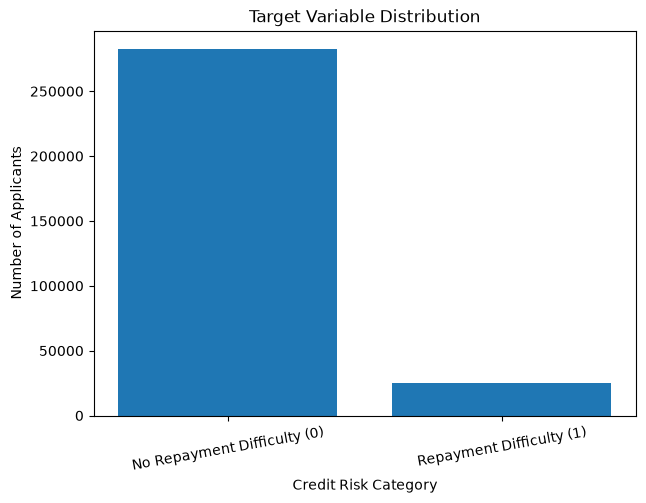

In [143]:
target_counts = df_clean["TARGET"].value_counts().sort_index()
target_percentages = df_clean["TARGET"].value_counts(
    normalize=True
).sort_index() * 100

print("Target Distribution:")
print(target_counts)

print("\nTarget Percentage:")
for target, percentage in target_percentages.items():
    print(f"TARGET {target}: {percentage:.2f}%")

plt.figure(figsize=(7, 5))

plt.bar(
    ["No Repayment Difficulty (0)", "Repayment Difficulty (1)"],
    target_counts.values
)

plt.title("Target Variable Distribution")
plt.xlabel("Credit Risk Category")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=10)

plt.show()


### Class Imbalance Observation

The target variable is highly imbalanced.

Most applicants belong to `TARGET = 0`, while a much smaller group belongs to `TARGET = 1`. Therefore, accuracy alone may not give a reliable view of model performance.

Precision, Recall, F1-Score, and ROC-AUC will be used during model evaluation. Class imbalance will also be considered during model development.


### Distribution of Key Financial Features

Key financial features are analyzed to understand their distribution and identify unusual values or extreme observations.

The analysis focuses on income, credit amount, annuity, and goods price because these variables describe important financial characteristics of applicants.


In [144]:
financial_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE"
]

df_clean[financial_features].describe().T


,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1615.5,16524.0,24903.0,34596.0,258025.5
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,40500.0,238500.0,450000.0,679500.0,4050000.0


### Financial Feature Distributions

The distributions of income, credit amount, annuity, and goods price are visualized to identify skewness and extreme values.

This analysis helps determine whether transformation or outlier handling may be useful during later preprocessing.


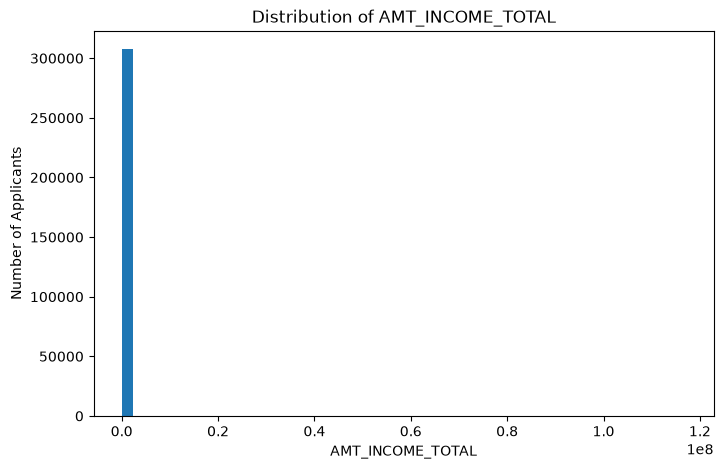

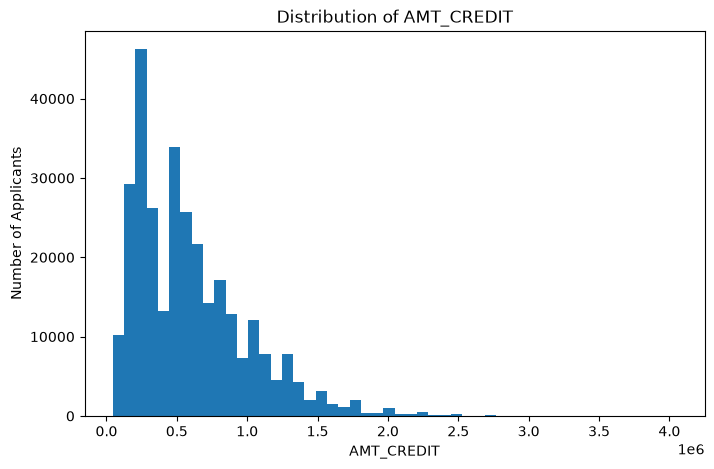

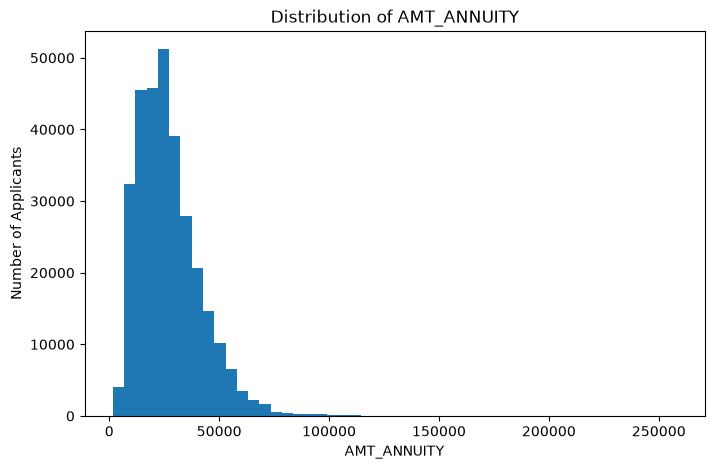

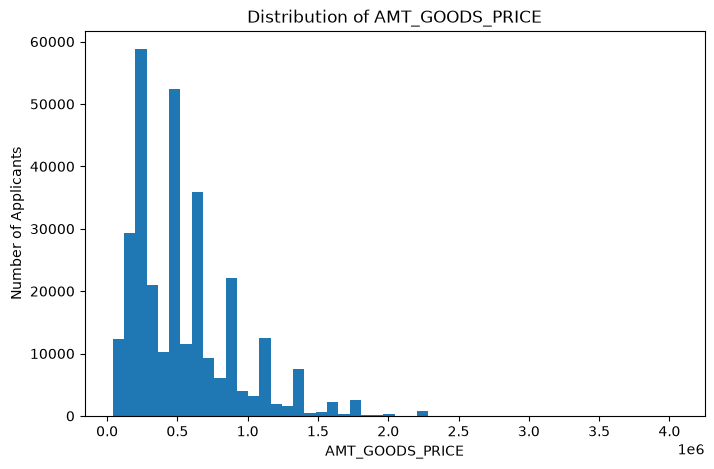

In [145]:
financial_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE"
]

for feature in financial_features:
    plt.figure(figsize=(8, 5))
    
    plt.hist(df_clean[feature], bins=50)
    
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Number of Applicants")
    
    plt.show()


### Financial Features and Credit Risk

The relationship between key financial features and the target variable is analyzed to understand whether financial characteristics differ between applicants with and without repayment difficulties.

The analysis focuses on income, credit amount, annuity, and goods price.


In [146]:
income_by_target = df_clean.groupby("TARGET")["AMT_INCOME_TOTAL"].median()

print("Median income by target:")
print(income_by_target)


Median income by target:
TARGET
0    148500.0
1    135000.0
Name: AMT_INCOME_TOTAL, dtype: float64


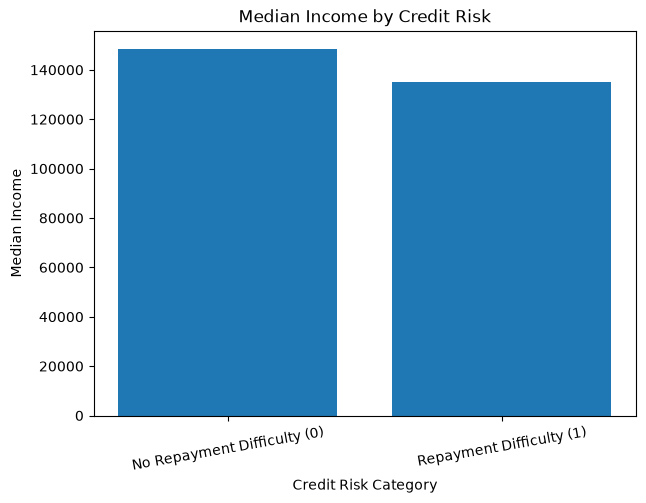

In [147]:
plt.figure(figsize=(7, 5))

plt.bar(
    ["No Repayment Difficulty (0)", "Repayment Difficulty (1)"],
    income_by_target.values
)

plt.title("Median Income by Credit Risk")
plt.xlabel("Credit Risk Category")
plt.ylabel("Median Income")

plt.xticks(rotation=10)
plt.show()


### Credit Amount and Credit Risk

The relationship between credit amount and repayment difficulty is analyzed to understand whether the requested credit amount differs between the two target groups.


In [148]:
credit_by_target = df_clean.groupby("TARGET")["AMT_CREDIT"].median()

print("Median credit amount by target:")
print(credit_by_target)


Median credit amount by target:
TARGET
0    517788.0
1    497520.0
Name: AMT_CREDIT, dtype: float64


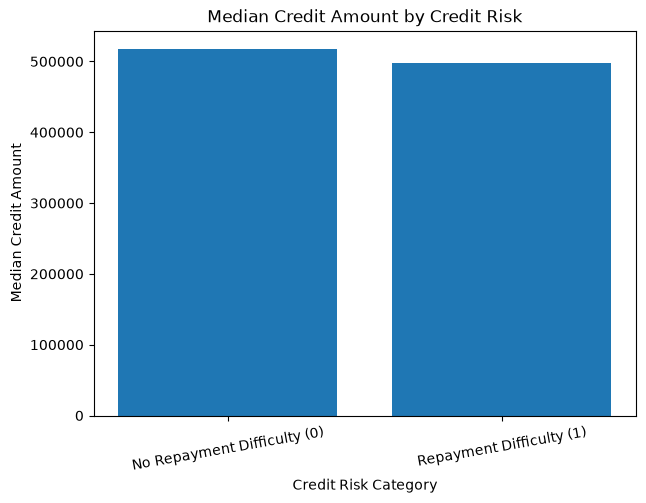

In [149]:
plt.figure(figsize=(7, 5))

plt.bar(
    ["No Repayment Difficulty (0)", "Repayment Difficulty (1)"],
    credit_by_target.values
)

plt.title("Median Credit Amount by Credit Risk")
plt.xlabel("Credit Risk Category")
plt.ylabel("Median Credit Amount")

plt.xticks(rotation=10)
plt.show()


### Annuity Amount and Credit Risk

The relationship between annuity amount and repayment difficulty is analyzed to understand whether the regular loan payment amount differs between the two target groups.


In [150]:
annuity_by_target = df_clean.groupby("TARGET")["AMT_ANNUITY"].median()

print("Median annuity amount by target:")
print(annuity_by_target)


Median annuity amount by target:
TARGET
0    24876.0
1    25263.0
Name: AMT_ANNUITY, dtype: float64


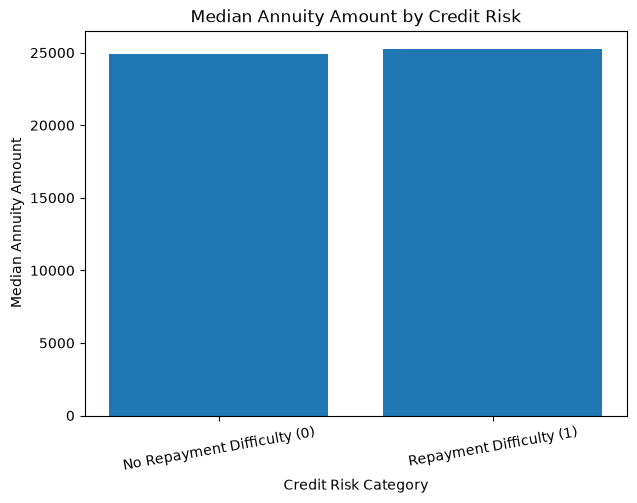

In [151]:
plt.figure(figsize=(7, 5))

plt.bar(
    ["No Repayment Difficulty (0)", "Repayment Difficulty (1)"],
    annuity_by_target.values
)

plt.title("Median Annuity Amount by Credit Risk")
plt.xlabel("Credit Risk Category")
plt.ylabel("Median Annuity Amount")

plt.xticks(rotation=10)
plt.show()


### Goods Price and Credit Risk

The relationship between goods price and repayment difficulty is analyzed to understand whether the price of the goods associated with the loan differs between the two target groups.


In [152]:
goods_price_by_target = df_clean.groupby("TARGET")["AMT_GOODS_PRICE"].median()

print("Median goods price by target:")
print(goods_price_by_target)


Median goods price by target:
TARGET
0    450000.0
1    450000.0
Name: AMT_GOODS_PRICE, dtype: float64


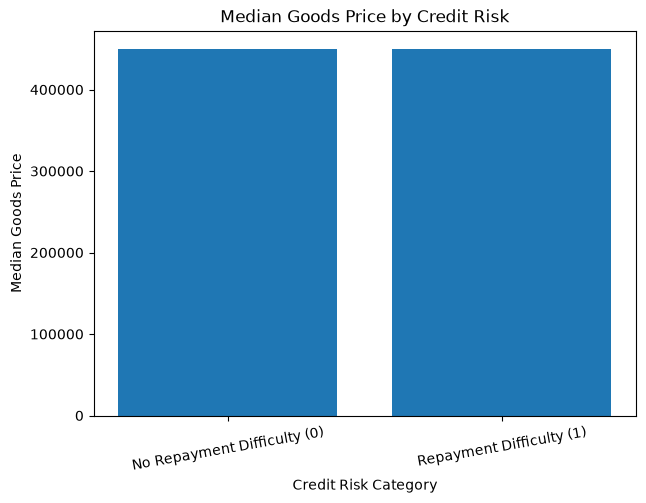

In [153]:
plt.figure(figsize=(7, 5))

plt.bar(
    ["No Repayment Difficulty (0)", "Repayment Difficulty (1)"],
    goods_price_by_target.values
)

plt.title("Median Goods Price by Credit Risk")
plt.xlabel("Credit Risk Category")
plt.ylabel("Median Goods Price")

plt.xticks(rotation=10)
plt.show()


### Key Findings from Financial Analysis

The median values of major financial features were compared between applicants with and without repayment difficulties.

- Applicants with repayment difficulty had a slightly lower median income.
- The median credit amount was slightly lower for applicants with repayment difficulty.
- The median annuity amount was slightly higher for applicants with repayment difficulty.
- The median goods price was the same for both target groups.

These comparisons show that individual financial features do not always provide a strong separation between the two target groups. Therefore, multiple features should be combined during model training to improve credit risk prediction.


### Target Rate by Applicant Group

The comparisons above look at average values per target group. It is also useful to look at the problem from the other direction and check the repayment-difficulty rate inside different applicant groups.

Age, income level, education, and income type are used because they are complete columns and are commonly related to credit behaviour. The overall target rate is around 8%, so the interesting part is which groups sit clearly above or below that level.


In [154]:
# Age and income are grouped into bands for this analysis only
eda = df_clean[[
    "TARGET",
    "DAYS_BIRTH",
    "AMT_INCOME_TOTAL",
    "NAME_EDUCATION_TYPE",
    "NAME_INCOME_TYPE"
]].copy()

eda["AGE_YEARS"] = (-eda["DAYS_BIRTH"] / 365).round(0)

eda["AGE_BAND"] = pd.cut(
    eda["AGE_YEARS"],
    bins=[20, 30, 40, 50, 60, 70],
    labels=["20-30", "30-40", "40-50", "50-60", "60-70"]
)

eda["INCOME_BAND"] = pd.qcut(
    eda["AMT_INCOME_TOTAL"],
    q=5,
    labels=["Lowest 20%", "Low", "Middle", "High", "Highest 20%"]
)

overall_rate = eda["TARGET"].mean()
print("Overall target rate:", round(overall_rate * 100, 2), "%")

age_rate = eda.groupby("AGE_BAND", observed=True)["TARGET"].mean() * 100
income_rate = eda.groupby("INCOME_BAND", observed=True)["TARGET"].mean() * 100

print("\nTarget rate by age band (%):")
print(age_rate.round(2))

print("\nTarget rate by income band (%):")
print(income_rate.round(2))


Overall target rate: 8.07 %

Target rate by age band (%):
AGE_BAND
20-30    11.44
30-40     9.43
40-50     7.58
50-60     6.04
60-70     4.92
Name: TARGET, dtype: float64

Target rate by income band (%):
INCOME_BAND
Lowest 20%     8.21
Low            8.59
Middle         8.68
High           8.06
Highest 20%    6.52
Name: TARGET, dtype: float64


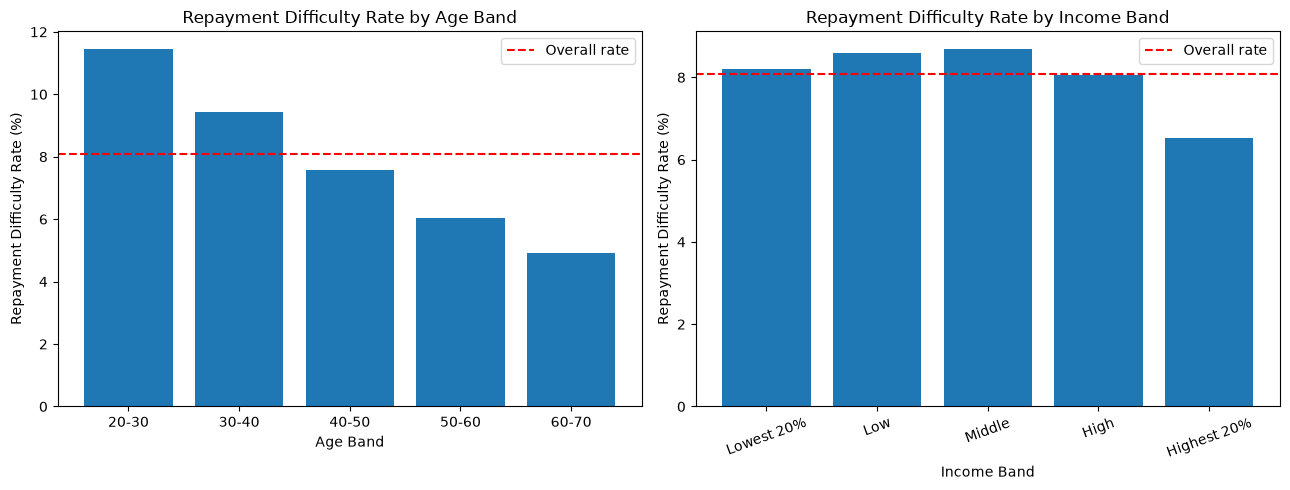

In [155]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(age_rate.index.astype(str), age_rate.values)
axes[0].axhline(overall_rate * 100, linestyle="--", color="red",
                label="Overall rate")
axes[0].set_title("Repayment Difficulty Rate by Age Band")
axes[0].set_xlabel("Age Band")
axes[0].set_ylabel("Repayment Difficulty Rate (%)")
axes[0].legend()

axes[1].bar(income_rate.index.astype(str), income_rate.values)
axes[1].axhline(overall_rate * 100, linestyle="--", color="red",
                label="Overall rate")
axes[1].set_title("Repayment Difficulty Rate by Income Band")
axes[1].set_xlabel("Income Band")
axes[1].set_ylabel("Repayment Difficulty Rate (%)")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend()

plt.tight_layout()
plt.show()


Target rate by education (%):
NAME_EDUCATION_TYPE
Academic degree                   1.83
Higher education                  5.36
Incomplete higher                 8.48
Secondary / secondary special     8.94
Lower secondary                  10.93
Name: TARGET, dtype: float64

Target rate by income type (%):
NAME_INCOME_TYPE
Businessman              0.00
Student                  0.00
Pensioner                5.39
State servant            5.75
Commercial associate     7.48
Working                  9.59
Unemployed              36.36
Maternity leave         40.00
Name: TARGET, dtype: float64


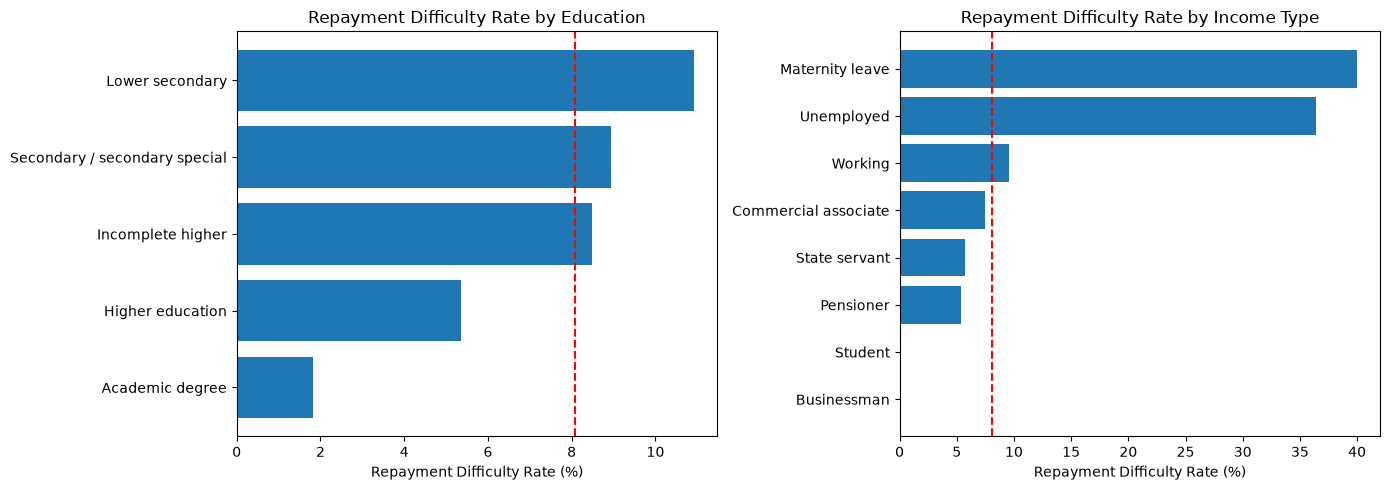

In [156]:
education_rate = (
    eda.groupby("NAME_EDUCATION_TYPE")["TARGET"].mean() * 100
).sort_values()

income_type_rate = (
    eda.groupby("NAME_INCOME_TYPE")["TARGET"].mean() * 100
).sort_values()

print("Target rate by education (%):")
print(education_rate.round(2))

print("\nTarget rate by income type (%):")
print(income_type_rate.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(education_rate.index, education_rate.values)
axes[0].axvline(overall_rate * 100, linestyle="--", color="red")
axes[0].set_title("Repayment Difficulty Rate by Education")
axes[0].set_xlabel("Repayment Difficulty Rate (%)")

axes[1].barh(income_type_rate.index, income_type_rate.values)
axes[1].axvline(overall_rate * 100, linestyle="--", color="red")
axes[1].set_title("Repayment Difficulty Rate by Income Type")
axes[1].set_xlabel("Repayment Difficulty Rate (%)")

plt.tight_layout()
plt.show()


The red line in each chart is the overall repayment-difficulty rate, so any bar clearly above or below it marks a group that behaves differently from the average applicant.

Group-level rates like these separate applicants more clearly than the median financial values compared earlier, which is one reason the models later use the full feature set instead of a few financial columns.


## 9. Historical Credit Data Integration

Historical credit information is integrated to improve the representation of an applicant's past financial behavior.

The Bureau dataset contains previous credit information associated with applicants through `SK_ID_CURR`.


In [157]:
bureau = pd.read_csv(RAW_DATA / "bureau.csv")

print("Bureau dataset shape:", bureau.shape)
bureau.head()


Bureau dataset shape: (1716428, 17)


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


### Bureau Records per Applicant

Each applicant can have multiple historical credit records in the Bureau dataset.

Therefore, the number of Bureau records per applicant is examined before creating aggregated historical features.


In [158]:
bureau_records_per_customer = bureau.groupby("SK_ID_CURR").size()

print("Average bureau records per applicant:",
      bureau_records_per_customer.mean())

print("Maximum bureau records for one applicant:",
      bureau_records_per_customer.max())


Average bureau records per applicant: 5.612708502964249
Maximum bureau records for one applicant: 116


### Bureau Feature Engineering

The Bureau dataset contains multiple records for each applicant.

To combine this information with the main applicant dataset, historical credit records are aggregated by `SK_ID_CURR`.

The following features are created:
- Total number of previous credit records
- Total previous credit amount
- Total previous debt
- Average days since previous credit
- Number of overdue credit records


In [159]:
bureau_features = bureau.groupby("SK_ID_CURR").agg(
    BUREAU_CREDIT_COUNT=("SK_ID_BUREAU", "count"),
    BUREAU_TOTAL_CREDIT=("AMT_CREDIT_SUM", "sum"),
    BUREAU_TOTAL_DEBT=("AMT_CREDIT_SUM_DEBT", "sum"),
    BUREAU_AVG_DAYS_CREDIT=("DAYS_CREDIT", "mean"),
    BUREAU_OVERDUE_COUNT=("CREDIT_DAY_OVERDUE", lambda x: (x > 0).sum())
).reset_index()

print("Bureau feature shape:", bureau_features.shape)

bureau_features.head()


Bureau feature shape: (305811, 6)


,SK_ID_CURR,BUREAU_CREDIT_COUNT,BUREAU_TOTAL_CREDIT,BUREAU_TOTAL_DEBT,BUREAU_AVG_DAYS_CREDIT,BUREAU_OVERDUE_COUNT
0,100001,7,1453365.000,596686.5,-735.000000,0
1,100002,8,865055.565,245781.0,-874.000000,0
2,100003,4,1017400.500,0.0,-1400.750000,0
3,100004,2,189037.800,0.0,-867.000000,0
4,100005,3,657126.000,568408.5,-190.666667,0


In [160]:
df_model = df_clean.merge(
    bureau_features,
    on="SK_ID_CURR",
    how="left"
)

print("Dataset shape after bureau integration:", df_model.shape)

print("\nNew bureau features:")
print([
    "BUREAU_CREDIT_COUNT",
    "BUREAU_TOTAL_CREDIT",
    "BUREAU_TOTAL_DEBT",
    "BUREAU_AVG_DAYS_CREDIT",
    "BUREAU_OVERDUE_COUNT"
])

df_model.head()


Dataset shape after bureau integration: (307511, 82)

New bureau features:
['BUREAU_CREDIT_COUNT', 'BUREAU_TOTAL_CREDIT', 'BUREAU_TOTAL_DEBT', 'BUREAU_AVG_DAYS_CREDIT', 'BUREAU_OVERDUE_COUNT']


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,DAYS_EMPLOYED_MISSING,BUREAU_CREDIT_COUNT,BUREAU_TOTAL_CREDIT,BUREAU_TOTAL_DEBT,BUREAU_AVG_DAYS_CREDIT,BUREAU_OVERDUE_COUNT
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,1.0,0,8.0,865055.565,245781.0,-874.00,0.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0,4.0,1017400.500,0.0,-1400.75,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0,2.0,189037.800,0.0,-867.00,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0,1.0,146250.000,0.0,-1149.00,0.0


In [161]:
bureau_feature_cols = [
    "BUREAU_CREDIT_COUNT",
    "BUREAU_TOTAL_CREDIT",
    "BUREAU_TOTAL_DEBT",
    "BUREAU_AVG_DAYS_CREDIT",
    "BUREAU_OVERDUE_COUNT"
]

print(df_model[bureau_feature_cols].isnull().sum())


BUREAU_CREDIT_COUNT       44020
BUREAU_TOTAL_CREDIT       44020
BUREAU_TOTAL_DEBT         44020
BUREAU_AVG_DAYS_CREDIT    44020
BUREAU_OVERDUE_COUNT      44020
dtype: int64


### Handling Missing Historical Credit Features

Some applicants do not have previous credit records in the Bureau dataset.

For count and amount features, a missing value means there is no history, so these are set to 0. This keeps a real difference between "no credit history" and "history with a value of zero".

`BUREAU_AVG_DAYS_CREDIT` is different. There is no meaningful zero for the average age of a credit history, so it is left missing and imputed later by the preprocessing pipeline, which is fitted only on the training data.


In [162]:
count_features = [
    "BUREAU_CREDIT_COUNT",
    "BUREAU_TOTAL_CREDIT",
    "BUREAU_TOTAL_DEBT",
    "BUREAU_OVERDUE_COUNT"
]

df_model[count_features] = df_model[count_features].fillna(0)

print("Missing values in bureau features:")
print(df_model[bureau_feature_cols].isnull().sum())


Missing values in bureau features:
BUREAU_CREDIT_COUNT           0
BUREAU_TOTAL_CREDIT           0
BUREAU_TOTAL_DEBT             0
BUREAU_AVG_DAYS_CREDIT    44020
BUREAU_OVERDUE_COUNT          0
dtype: int64


### Final Check of Bureau Feature Integration

The aggregated Bureau features have been successfully integrated into the main applicant dataset.

All newly created historical credit features contain no missing values after handling applicants without available Bureau records.


In [163]:
print("Final dataset shape:", df_model.shape)

print("\nBureau feature summary:")
print(df_model[bureau_feature_cols].describe())


Final dataset shape: (307511, 82)

Bureau feature summary:
       BUREAU_CREDIT_COUNT  BUREAU_TOTAL_CREDIT  BUREAU_TOTAL_DEBT  \
count        307511.000000         3.075110e+05       3.075110e+05   
mean              4.765114         1.675834e+06       5.489416e+05   
std               4.496199         3.858106e+06       1.529047e+06   
min               0.000000         0.000000e+00      -6.981558e+06   
25%               1.000000         1.539495e+05       0.000000e+00   
50%               4.000000         7.110000e+05       8.758350e+04   
75%               7.000000         1.970993e+06       5.348565e+05   
max             116.000000         1.017958e+09       3.344983e+08   

       BUREAU_AVG_DAYS_CREDIT  BUREAU_OVERDUE_COUNT  
count           263491.000000         307511.000000  
mean             -1083.047110              0.012052  
std                563.327298              0.121765  
min              -2922.000000              0.000000  
25%              -1434.000000           

### Previous Application History

The Previous Application dataset contains information about applicants' earlier loan applications.

This historical information can provide additional insights into an applicant's previous credit application behavior.

The data will be aggregated by `SK_ID_CURR` before being merged with the main applicant dataset.


In [164]:
previous_application = pd.read_csv(RAW_DATA / "previous_application.csv")

print("Previous Application dataset shape:", previous_application.shape)


Previous Application dataset shape: (1670214, 37)


### Previous Application Feature Analysis

The Previous Application dataset contains multiple historical loan applications for each applicant.

The available features are reviewed before aggregation to identify meaningful indicators of previous application behavior.


In [165]:
print("Previous Application columns:")
print(previous_application.columns.tolist())
previous_application.head()


Previous Application columns:
['SK_ID_PREV', 'SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'AMT_ANNUITY', 'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'FLAG_LAST_APPL_PER_CONTRACT', 'NFLAG_LAST_APPL_IN_DAY', 'RATE_DOWN_PAYMENT', 'RATE_INTEREST_PRIMARY', 'RATE_INTEREST_PRIVILEGED', 'NAME_CASH_LOAN_PURPOSE', 'NAME_CONTRACT_STATUS', 'DAYS_DECISION', 'NAME_PAYMENT_TYPE', 'CODE_REJECT_REASON', 'NAME_TYPE_SUITE', 'NAME_CLIENT_TYPE', 'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO', 'NAME_PRODUCT_TYPE', 'CHANNEL_TYPE', 'SELLERPLACE_AREA', 'NAME_SELLER_INDUSTRY', 'CNT_PAYMENT', 'NAME_YIELD_GROUP', 'PRODUCT_COMBINATION', 'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_LAST_DUE', 'DAYS_TERMINATION', 'NFLAG_INSURED_ON_APPROVAL']


,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


### Previous Application Records per Applicant

Each applicant can have multiple previous applications in the dataset.

Therefore, the number of previous application records per applicant is examined before creating aggregated historical features.


In [166]:
previous_application.groupby("SK_ID_CURR").size().describe()


count    338857.000000
mean          4.928964
std           4.220716
min           1.000000
25%           2.000000
50%           4.000000
75%           7.000000
max          77.000000
dtype: float64

### Previous Application Feature Engineering

The `previous_application` dataset contains information about an applicant's previous loan applications.

Each applicant may have multiple previous applications. Therefore, the records are aggregated by `SK_ID_CURR` to create applicant-level historical features.

These features help the model capture previous credit application behavior, such as the number of previous applications, approval history, and previous credit amounts.


In [167]:
previous_application_features = previous_application.groupby("SK_ID_CURR").agg(
    PREV_APP_COUNT=("SK_ID_PREV", "count"),
    PREV_APPROVED_COUNT=("NAME_CONTRACT_STATUS", lambda x: (x == "Approved").sum()),
    PREV_REFUSED_COUNT=("NAME_CONTRACT_STATUS", lambda x: (x == "Refused").sum()),
    PREV_TOTAL_CREDIT=("AMT_CREDIT", "sum"),
    PREV_AVG_CREDIT=("AMT_CREDIT", "mean")
).reset_index()

print("Previous application features created successfully!")
print("Shape:", previous_application_features.shape)

previous_application_features.head()


KeyboardInterrupt: 

### Integrating Previous Application Features

The aggregated previous application features are merged with the main modeling dataset using `SK_ID_CURR`.

This combines current application information with historical application behavior for each applicant.

The merged dataset provides additional historical features that can help the model assess creditworthiness.


In [ ]:
df_model = df_model.merge(
    previous_application_features,
    on="SK_ID_CURR",
    how="left"
)

print("Previous application features merged successfully!")
print("New shape:", df_model.shape)

df_model.head()


Previous application features merged successfully!
New shape: (307511, 87)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,BUREAU_CREDIT_COUNT,BUREAU_TOTAL_CREDIT,BUREAU_TOTAL_DEBT,BUREAU_AVG_DAYS_CREDIT,BUREAU_OVERDUE_COUNT,PREV_APP_COUNT,PREV_APPROVED_COUNT,PREV_REFUSED_COUNT,PREV_TOTAL_CREDIT,PREV_AVG_CREDIT
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,8.0,865055.565,245781.0,-874.00,0.0,1.0,1.0,0.0,179055.0,179055.00
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,4.0,1017400.500,0.0,-1400.75,0.0,3.0,3.0,0.0,1452573.0,484191.00
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,2.0,189037.800,0.0,-867.00,0.0,1.0,1.0,0.0,20106.0,20106.00
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.000,0.0,NaN,0.0,9.0,5.0,1.0,2625259.5,291695.50
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,1.0,146250.000,0.0,-1149.00,0.0,6.0,6.0,0.0,999832.5,166638.75


In [ ]:
print("df_clean shape:", df_clean.shape)
print("df_model shape:", df_model.shape)

print("\nPrevious application features:")
print(previous_application_features.columns.tolist())

print("\nNew previous-application columns in df_model:")
print([
    col for col in previous_application_features.columns
    if col != "SK_ID_CURR" and col in df_model.columns
])


df_clean shape: (307511, 77)
df_model shape: (307511, 87)

Previous application features:
['SK_ID_CURR', 'PREV_APP_COUNT', 'PREV_APPROVED_COUNT', 'PREV_REFUSED_COUNT', 'PREV_TOTAL_CREDIT', 'PREV_AVG_CREDIT']

New previous-application columns in df_model:
['PREV_APP_COUNT', 'PREV_APPROVED_COUNT', 'PREV_REFUSED_COUNT', 'PREV_TOTAL_CREDIT', 'PREV_AVG_CREDIT']


### Handling Missing Historical Features

Some applicants may not have any previous loan application history. After merging the aggregated historical features, these applicants have missing values.

Since the missing values indicate the absence of previous application history, they are replaced with zero.

This allows the model to distinguish applicants with no previous credit application history from applicants with existing historical records.


In [ ]:
previous_feature_cols = [
    "PREV_APP_COUNT",
    "PREV_APPROVED_COUNT",
    "PREV_REFUSED_COUNT",
    "PREV_TOTAL_CREDIT",
    "PREV_AVG_CREDIT"
]

df_model[previous_feature_cols] = (
    df_model[previous_feature_cols].fillna(0)
)

print("Missing historical values handled successfully!")

print("\nRemaining missing values:")
print(df_model[previous_feature_cols].isnull().sum())


Missing historical values handled successfully!

Remaining missing values:
PREV_APP_COUNT         0
PREV_APPROVED_COUNT    0
PREV_REFUSED_COUNT     0
PREV_TOTAL_CREDIT      0
PREV_AVG_CREDIT        0
dtype: int64


### Feature Engineering from Previous Application History

Additional features are created from the aggregated previous application data to better represent an applicant's historical credit behavior.

The approval rate and refusal rate show the proportion of previous applications that were approved or refused.

These derived features provide more meaningful information than using only the raw application counts.


In [ ]:
# Calculate previous application approval and refusal rates

df_model["PREV_APPROVAL_RATE"] = (
    df_model["PREV_APPROVED_COUNT"] / df_model["PREV_APP_COUNT"]
)

df_model["PREV_REFUSAL_RATE"] = (
    df_model["PREV_REFUSED_COUNT"] / df_model["PREV_APP_COUNT"]
)

print("Approval and refusal rates created successfully!")

df_model[
    [
        "SK_ID_CURR",
        "PREV_APP_COUNT",
        "PREV_APPROVED_COUNT",
        "PREV_REFUSED_COUNT",
        "PREV_APPROVAL_RATE",
        "PREV_REFUSAL_RATE"
    ]
].head()


Approval and refusal rates created successfully!


,SK_ID_CURR,PREV_APP_COUNT,PREV_APPROVED_COUNT,PREV_REFUSED_COUNT,PREV_APPROVAL_RATE,PREV_REFUSAL_RATE
0,100002,1.0,1.0,0.0,1.000000,0.000000
1,100003,3.0,3.0,0.0,1.000000,0.000000
2,100004,1.0,1.0,0.0,1.000000,0.000000
3,100006,9.0,5.0,1.0,0.555556,0.111111
4,100007,6.0,6.0,0.0,1.000000,0.000000


### Bureau Credit Utilization Feature

The bureau dataset contains information about an applicant's previous credits from other financial institutions.

A debt-to-credit ratio is created by comparing the applicant's total historical debt with their total historical credit amount.

This feature provides a normalized measure of the applicant's historical debt burden.


In [ ]:
# Create historical debt-to-credit ratio

df_model["BUREAU_DEBT_TO_CREDIT_RATIO"] = (
    df_model["BUREAU_TOTAL_DEBT"] /
    df_model["BUREAU_TOTAL_CREDIT"]
)

print("Bureau debt-to-credit ratio created successfully!")

df_model[
    [
        "SK_ID_CURR",
        "BUREAU_TOTAL_CREDIT",
        "BUREAU_TOTAL_DEBT",
        "BUREAU_DEBT_TO_CREDIT_RATIO"
    ]
].head()


Bureau debt-to-credit ratio created successfully!


,SK_ID_CURR,BUREAU_TOTAL_CREDIT,BUREAU_TOTAL_DEBT,BUREAU_DEBT_TO_CREDIT_RATIO
0,100002,865055.565,245781.0,0.284122
1,100003,1017400.500,0.0,0.000000
2,100004,189037.800,0.0,0.000000
3,100006,0.000,0.0,NaN
4,100007,146250.000,0.0,0.000000


### Handling Zero Historical Credit

Some applicants have no previous credit records, so their total historical credit is zero and the debt-to-credit ratio cannot be calculated. The division also produces infinite values where debt is positive but total credit is zero.

Infinite values are converted to missing first, and the ratio is then set to 0 for applicants with no historical credit, which matches their zero credit and zero debt values.


In [ ]:
# Division by zero can create infinite values
df_model["BUREAU_DEBT_TO_CREDIT_RATIO"] = (
    df_model["BUREAU_DEBT_TO_CREDIT_RATIO"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

print(
    "Missing values:",
    df_model["BUREAU_DEBT_TO_CREDIT_RATIO"].isnull().sum()
)

print(
    "Infinite values:",
    np.isinf(df_model["BUREAU_DEBT_TO_CREDIT_RATIO"]).sum()
)


Missing values: 0
Infinite values: 0


## 10. Installment Payment History Integration

The installment payment history is integrated to capture applicants' previous repayment behavior.

The dataset contains historical installment and payment information. Applicant-level features will be created by aggregating these records using `SK_ID_CURR`.

These features provide additional information about payment amounts, installment amounts, and repayment behavior for credit risk prediction.


In [ ]:
installments = pd.read_csv(RAW_DATA / "installments_payments.csv")

print("Installments dataset shape:", installments.shape)

print("\nInstallments columns:")
print(installments.columns.tolist())


Installments dataset shape: (13605401, 8)

Installments columns:
['SK_ID_PREV', 'SK_ID_CURR', 'NUM_INSTALMENT_VERSION', 'NUM_INSTALMENT_NUMBER', 'DAYS_INSTALMENT', 'DAYS_ENTRY_PAYMENT', 'AMT_INSTALMENT', 'AMT_PAYMENT']


In [ ]:
print("First 5 rows:")
display(installments.head())

print("\nMissing values:")
print(
    installments.isnull().sum()
    .sort_values(ascending=False)
    .head(15)
)


First 5 rows:


,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585



Missing values:
AMT_PAYMENT               2905
DAYS_ENTRY_PAYMENT        2905
SK_ID_PREV                   0
SK_ID_CURR                   0
NUM_INSTALMENT_NUMBER        0
NUM_INSTALMENT_VERSION       0
DAYS_INSTALMENT              0
AMT_INSTALMENT               0
dtype: int64


### Installment Payment Behavior Feature Engineering

Features are created from the installment payment history to capture applicants' previous repayment behavior.

Payment delay, total payment amount, installment amount, and payment frequency are aggregated at the applicant level using `SK_ID_CURR`.

These features provide additional historical financial information for credit risk prediction.


In [ ]:
# Calculate payment delay
installments["DAYS_DELAY"] = (
    installments["DAYS_ENTRY_PAYMENT"]
    - installments["DAYS_INSTALMENT"]
)

# Calculate payment difference
installments["PAYMENT_DIFFERENCE"] = (
    installments["AMT_PAYMENT"]
    - installments["AMT_INSTALMENT"]
)

# Calculate payment ratio
installments["PAYMENT_RATIO"] = (
    installments["AMT_PAYMENT"]
    / installments["AMT_INSTALMENT"]
)

# Replace infinite values created by division
installments["PAYMENT_RATIO"] = (
    installments["PAYMENT_RATIO"]
    .replace([np.inf, -np.inf], np.nan)
)

print("Installment-level features created successfully!")

display(
    installments[
        [
            "SK_ID_CURR",
            "AMT_INSTALMENT",
            "AMT_PAYMENT",
            "DAYS_INSTALMENT",
            "DAYS_ENTRY_PAYMENT",
            "DAYS_DELAY",
            "PAYMENT_DIFFERENCE",
            "PAYMENT_RATIO"
        ]
    ].head()
)


Installment-level features created successfully!


,SK_ID_CURR,AMT_INSTALMENT,AMT_PAYMENT,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,DAYS_DELAY,PAYMENT_DIFFERENCE,PAYMENT_RATIO
0,161674,6948.360,6948.360,-1180.0,-1187.0,-7.0,0.000,1.000000
1,151639,1716.525,1716.525,-2156.0,-2156.0,0.0,0.000,1.000000
2,193053,25425.000,25425.000,-63.0,-63.0,0.0,0.000,1.000000
3,199697,24350.130,24350.130,-2418.0,-2426.0,-8.0,0.000,1.000000
4,167756,2165.040,2160.585,-1383.0,-1366.0,17.0,-4.455,0.997942


In [ ]:
installment_features = installments.groupby("SK_ID_CURR").agg(
    INSTALLMENT_COUNT=("SK_ID_PREV", "count"),
    INSTALLMENT_TOTAL_PAYMENT=("AMT_PAYMENT", "sum"),
    INSTALLMENT_TOTAL_DUE=("AMT_INSTALMENT", "sum"),
    INSTALLMENT_AVG_PAYMENT=("AMT_PAYMENT", "mean"),
    INSTALLMENT_AVG_DELAY=("DAYS_DELAY", "mean"),
    INSTALLMENT_LATE_COUNT=("DAYS_DELAY", lambda x: (x > 0).sum()),
    INSTALLMENT_AVG_PAYMENT_RATIO=("PAYMENT_RATIO", "mean"),
    INSTALLMENT_MISSING_PAYMENT_COUNT=(
        "AMT_PAYMENT",
        lambda x: x.isnull().sum()
    )
).reset_index()

print("Installment features created successfully!")

print("Shape:", installment_features.shape)

display(installment_features.head())


Installment features created successfully!
Shape: (339587, 9)


,SK_ID_CURR,INSTALLMENT_COUNT,INSTALLMENT_TOTAL_PAYMENT,INSTALLMENT_TOTAL_DUE,INSTALLMENT_AVG_PAYMENT,INSTALLMENT_AVG_DELAY,INSTALLMENT_LATE_COUNT,INSTALLMENT_AVG_PAYMENT_RATIO,INSTALLMENT_MISSING_PAYMENT_COUNT
0,100001,7,41195.925,41195.925,5885.132143,-7.285714,1,1.0,0
1,100002,19,219625.695,219625.695,11559.247105,-20.421053,0,1.0,0
2,100003,25,1618864.650,1618864.650,64754.586000,-7.160000,0,1.0,0
3,100004,3,21288.465,21288.465,7096.155000,-7.666667,0,1.0,0
4,100005,9,56161.845,56161.845,6240.205000,-23.555556,1,1.0,0


### Integrating Installment Payment Features

The aggregated installment payment features are merged with the main modeling dataset using `SK_ID_CURR`.

This integration adds historical repayment behavior to the applicant-level dataset and allows the model to use previous payment patterns for credit risk prediction.


In [ ]:
df_model = df_model.merge(
    installment_features,
    on="SK_ID_CURR",
    how="left"
)

print("Installment features merged successfully!")
print("New df_model shape:", df_model.shape)

print("\nNew installment features:")
print([
    col for col in installment_features.columns
    if col != "SK_ID_CURR"
    and col in df_model.columns
])


Installment features merged successfully!
New df_model shape: (307511, 98)

New installment features:
['INSTALLMENT_COUNT', 'INSTALLMENT_TOTAL_PAYMENT', 'INSTALLMENT_TOTAL_DUE', 'INSTALLMENT_AVG_PAYMENT', 'INSTALLMENT_AVG_DELAY', 'INSTALLMENT_LATE_COUNT', 'INSTALLMENT_AVG_PAYMENT_RATIO', 'INSTALLMENT_MISSING_PAYMENT_COUNT']


### Handling Missing Installment History

Some applicants do not have previous installment payment records. After merging the aggregated installment features, these applicants have missing values.

For count and total amount features, missing values indicate the absence of installment history and are therefore replaced with zero.

For behavioral features such as average payment delay and payment ratio, missing values are handled separately because they represent the absence of historical payment information.


In [ ]:
installment_feature_cols = [
    "INSTALLMENT_COUNT",
    "INSTALLMENT_TOTAL_PAYMENT",
    "INSTALLMENT_TOTAL_DUE",
    "INSTALLMENT_AVG_PAYMENT",
    "INSTALLMENT_AVG_DELAY",
    "INSTALLMENT_LATE_COUNT",
    "INSTALLMENT_AVG_PAYMENT_RATIO",
    "INSTALLMENT_MISSING_PAYMENT_COUNT"
]

print("Missing values before handling:")
print(df_model[installment_feature_cols].isnull().sum())


Missing values before handling:
INSTALLMENT_COUNT                    15868
INSTALLMENT_TOTAL_PAYMENT            15868
INSTALLMENT_TOTAL_DUE                15868
INSTALLMENT_AVG_PAYMENT              15876
INSTALLMENT_AVG_DELAY                15876
INSTALLMENT_LATE_COUNT               15868
INSTALLMENT_AVG_PAYMENT_RATIO        15879
INSTALLMENT_MISSING_PAYMENT_COUNT    15868
dtype: int64


In [ ]:
zero_fill_features = [
    "INSTALLMENT_COUNT",
    "INSTALLMENT_TOTAL_PAYMENT",
    "INSTALLMENT_TOTAL_DUE",
    "INSTALLMENT_LATE_COUNT",
    "INSTALLMENT_MISSING_PAYMENT_COUNT"
]

df_model[zero_fill_features] = (
    df_model[zero_fill_features].fillna(0)
)

print("Count and total installment features handled successfully!")


Count and total installment features handled successfully!


In [ ]:
remaining_installment_missing = (
    df_model[installment_feature_cols]
    .isnull()
    .sum()
)

print("Remaining missing values in installment features:")
print(remaining_installment_missing)


Remaining missing values in installment features:
INSTALLMENT_COUNT                        0
INSTALLMENT_TOTAL_PAYMENT                0
INSTALLMENT_TOTAL_DUE                    0
INSTALLMENT_AVG_PAYMENT              15876
INSTALLMENT_AVG_DELAY                15876
INSTALLMENT_LATE_COUNT                   0
INSTALLMENT_AVG_PAYMENT_RATIO        15879
INSTALLMENT_MISSING_PAYMENT_COUNT        0
dtype: int64


### Final Handling of Installment Features

Applicants without previous installment records have zero values for count and total-payment features.

Behavioral features such as average payment, average payment delay, and payment ratio may remain missing when sufficient historical payment information is unavailable.

These remaining numerical missing values will be handled later by the machine learning preprocessing pipeline using median imputation.


### Historical Behaviour and Repayment Difficulty

The engineered historical features are checked against the target before modelling, to see whether past behaviour is related to the current outcome.

Late installment payments and the refusal rate of previous applications are used here because both describe behaviour rather than size, and both are available for most applicants.


Target rate by number of late installments (%):
LATE_BAND
0         6.72
1-5       9.15
6-20      9.82
21-50     9.71
50+      13.18
Name: TARGET, dtype: float64

Target rate by previous refusal rate (%):
REFUSAL_BAND
No history     5.96
0%             7.07
0-25%          8.11
25-50%        11.33
50-100%       15.93
Name: TARGET, dtype: float64


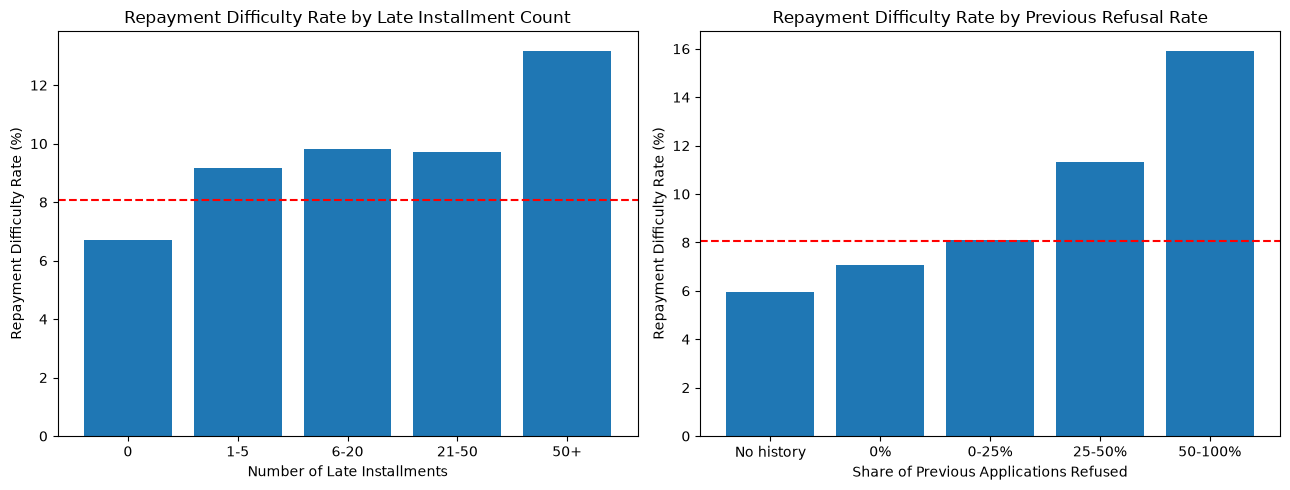

In [ ]:
history_eda = df_model[[
    "TARGET",
    "INSTALLMENT_LATE_COUNT",
    "PREV_REFUSAL_RATE"
]].copy()

history_eda["LATE_BAND"] = pd.cut(
    history_eda["INSTALLMENT_LATE_COUNT"],
    bins=[-1, 0, 5, 20, 50, np.inf],
    labels=["0", "1-5", "6-20", "21-50", "50+"]
)

history_eda["REFUSAL_BAND"] = pd.cut(
    history_eda["PREV_REFUSAL_RATE"].fillna(-1),
    bins=[-2, -0.5, 0.0001, 0.25, 0.5, 1.01],
    labels=["No history", "0%", "0-25%", "25-50%", "50-100%"]
)

late_rate = history_eda.groupby(
    "LATE_BAND", observed=True
)["TARGET"].mean() * 100

refusal_rate = history_eda.groupby(
    "REFUSAL_BAND", observed=True
)["TARGET"].mean() * 100

print("Target rate by number of late installments (%):")
print(late_rate.round(2))

print("\nTarget rate by previous refusal rate (%):")
print(refusal_rate.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(late_rate.index.astype(str), late_rate.values)
axes[0].axhline(df_model["TARGET"].mean() * 100, linestyle="--", color="red")
axes[0].set_title("Repayment Difficulty Rate by Late Installment Count")
axes[0].set_xlabel("Number of Late Installments")
axes[0].set_ylabel("Repayment Difficulty Rate (%)")

axes[1].bar(refusal_rate.index.astype(str), refusal_rate.values)
axes[1].axhline(df_model["TARGET"].mean() * 100, linestyle="--", color="red")
axes[1].set_title("Repayment Difficulty Rate by Previous Refusal Rate")
axes[1].set_xlabel("Share of Previous Applications Refused")
axes[1].set_ylabel("Repayment Difficulty Rate (%)")

plt.tight_layout()
plt.show()


The charts above show how the target rate changes across these historical groups. Any group sitting clearly above the red line has a higher repayment-difficulty rate than the average applicant.

This is only a description of the data, not proof that the historical features improve the model. That question is tested directly in the ablation experiment later in the notebook.


## 11. Feature Review

After integrating historical credit information and creating additional features, the final modeling dataset is reviewed before machine learning preprocessing.

The review checks the dataset shape, target variable, duplicate columns, missing values, and newly engineered features.

This step helps ensure that the dataset is consistent and ready for the next stage.


In [ ]:
# Final feature review

print("Dataset shape:", df_model.shape)

print("\nTARGET exists:", "TARGET" in df_model.columns)

print("\nDuplicate columns:", df_model.columns.duplicated().sum())

print("\nTotal missing values:", df_model.isnull().sum().sum())


print("\nEngineered features:")
print([
    "PREV_APPROVAL_RATE",
    "PREV_REFUSAL_RATE",
    "BUREAU_DEBT_TO_CREDIT_RATIO",
    "INSTALLMENT_COUNT",
    "INSTALLMENT_TOTAL_PAYMENT",
    "INSTALLMENT_TOTAL_DUE",
    "INSTALLMENT_AVG_PAYMENT",
    "INSTALLMENT_AVG_DELAY",
    "INSTALLMENT_LATE_COUNT",
    "INSTALLMENT_AVG_PAYMENT_RATIO",
    "INSTALLMENT_MISSING_PAYMENT_COUNT"
])

print("\nNumber of features:", len(df_model.columns))


Dataset shape: (307511, 98)

TARGET exists: True

Duplicate columns: 0

Total missing values: 871356

Engineered features:
['PREV_APPROVAL_RATE', 'PREV_REFUSAL_RATE', 'BUREAU_DEBT_TO_CREDIT_RATIO', 'INSTALLMENT_COUNT', 'INSTALLMENT_TOTAL_PAYMENT', 'INSTALLMENT_TOTAL_DUE', 'INSTALLMENT_AVG_PAYMENT', 'INSTALLMENT_AVG_DELAY', 'INSTALLMENT_LATE_COUNT', 'INSTALLMENT_AVG_PAYMENT_RATIO', 'INSTALLMENT_MISSING_PAYMENT_COUNT']

Number of features: 98


## 12. Preparing Data for Machine Learning

Before model training, the target variable and applicant ID are separated from the input features.

The `TARGET` column represents the outcome that the model needs to predict, so it is stored separately as the target variable.

The `SK_ID_CURR` column is an applicant identifier and does not provide predictive information, so it is excluded from the model features.


In [ ]:
# Separate target variable and applicant ID

y = df_model["TARGET"]

X = df_model.drop(columns=["TARGET", "SK_ID_CURR"])

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nNumber of numerical features:",
      X.select_dtypes(include=["int64", "float64"]).shape[1])

print("Number of categorical features:",
      X.select_dtypes(include=["object"]).shape[1])


Features shape: (307511, 96)
Target shape: (307511,)

Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Number of numerical features: 83
Number of categorical features: 13


C:\Users\User\AppData\Local\Temp\ipykernel_12184\1868661948.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X.select_dtypes(include=["object"]).shape[1])


## 13. Feature Type Separation

The dataset contains both numerical and categorical features.

Numerical features require missing value handling, while categorical features require missing value handling and encoding.

A preprocessing pipeline is used to apply these transformations consistently and avoid data leakage during model training.


### Separating Numerical and Categorical Features

The input features contain both numerical and categorical variables.

Numerical features contain quantitative values, while categorical features represent different categories.

The two types of features are separated because they require different preprocessing techniques before model training.


In [ ]:
# Separate numerical and categorical features

numerical_features = X.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("Number of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

print("\nCategorical features:")
print(categorical_features)


Number of numerical features: 83
Number of categorical features: 13

Categorical features:
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'EMERGENCYSTATE_MODE']


## 14. Train, Validation and Test Split

The data is split into three parts instead of two.

The training set is used to fit the preprocessing steps and the models. The validation set is used for every decision that comes after training: comparing models, running the ablation experiment, and choosing the classification threshold. The test set is used only once, at the end, to report the performance of the final frozen model.

This matters here because the threshold has a large effect on precision and recall. If the threshold is chosen on the test set, the reported test results are no longer an honest estimate of performance on new applicants.

The split is 60% training, 20% validation, and 20% test, done in two steps with stratification so that the target rate stays the same in all three sets.


In [ ]:
from sklearn.model_selection import train_test_split

# First split off the test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# Then split the remainder into training and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("Training set  :", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set      :", X_test.shape)

print("\nTarget rate in each set:")
print("Train     :", round(y_train.mean(), 4))
print("Validation:", round(y_val.mean(), 4))
print("Test      :", round(y_test.mean(), 4))


Training set  : (184506, 96)
Validation set: (61502, 96)
Test set      : (61503, 96)

Target rate in each set:
Train     : 0.0807
Validation: 0.0807
Test      : 0.0807


## 15. Preprocessing

Numerical and categorical features need different treatment, so a `ColumnTransformer` is used.

Numerical features are imputed with the median and then scaled. Scaling is needed by Logistic Regression and does not harm the tree models. Categorical features are imputed with the most frequent value and converted with one-hot encoding, with `handle_unknown="ignore"` so that a category that appears only in validation or test data does not break the transform.

The important detail is that the transformer is fitted on the training set only. The medians, the scaling parameters, and the list of categories all come from training data, and validation and test data are only transformed.


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


def build_preprocessor(numeric_cols, categorical_cols):
    """Create the preprocessing transformer for a given set of columns."""
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    return ColumnTransformer(transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ])


preprocessor = build_preprocessor(numerical_features, categorical_features)
print("Preprocessor created.")


Preprocessor created.


### Infinite Values

Some engineered ratio features can produce infinite values when the denominator is zero. `SimpleImputer` cannot handle infinity, so these values are converted to `NaN` first and then imputed like any other missing value.

The same conversion is used later by the prediction helper, so new data goes through exactly the same step.


In [ ]:
def replace_infinite_values(data):
    """Convert infinite values to NaN so the imputer can handle them."""
    return data.replace([np.inf, -np.inf], np.nan)


print(
    "Infinite values before:",
    np.isinf(X_train.select_dtypes(include=["number"])).sum().sum()
)

X_train = replace_infinite_values(X_train)
X_val = replace_infinite_values(X_val)
X_test = replace_infinite_values(X_test)

print(
    "Infinite values after:",
    np.isinf(X_train.select_dtypes(include=["number"])).sum().sum()
)


Infinite values before: 0
Infinite values after: 0


In [ ]:
# Fit on training data only, then transform the other sets
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape  :", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)
print("Processed test shape      :", X_test_processed.shape)


Processed training shape  : (184506, 212)
Processed validation shape: (61502, 212)
Processed test shape      : (61503, 212)


## 16. Baseline Models

Three classification models are trained with reasonable default settings: Logistic Regression, Decision Tree, and Random Forest.

All three use `class_weight="balanced"` because only about 8% of applicants belong to the positive class. Without this, the models predict almost everything as low risk.

All baseline results in this section are reported on the **validation set**. The test set is not touched until the final evaluation.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    classification_report
)


def evaluate_predictions(y_true, y_pred, y_prob, model_name):
    """Return the metrics used throughout the project as a dict."""
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob)
    }


print("Positive class rate in validation set:", round(y_val.mean(), 4))


Positive class rate in validation set: 0.0807


### Logistic Regression


In [ ]:
logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_STATE
)

logistic_model.fit(X_train_processed, y_train)

y_pred_logistic = logistic_model.predict(X_val_processed)
y_prob_logistic = logistic_model.predict_proba(X_val_processed)[:, 1]

logistic_scores = evaluate_predictions(
    y_val, y_pred_logistic, y_prob_logistic, "Logistic Regression"
)

for metric, value in logistic_scores.items():
    if metric != "Model":
        print(f"{metric:<10}: {value:.4f}")


Accuracy  : 0.6940
Precision : 0.1639
Recall    : 0.6800
F1-Score  : 0.2641
ROC-AUC   : 0.7530
PR-AUC    : 0.2237


### Decision Tree


In [ ]:
decision_tree_model = DecisionTreeClassifier(
    class_weight="balanced",
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=RANDOM_STATE
)

decision_tree_model.fit(X_train_processed, y_train)

y_pred_tree = decision_tree_model.predict(X_val_processed)
y_prob_tree = decision_tree_model.predict_proba(X_val_processed)[:, 1]

tree_scores = evaluate_predictions(
    y_val, y_pred_tree, y_prob_tree, "Decision Tree"
)

for metric, value in tree_scores.items():
    if metric != "Model":
        print(f"{metric:<10}: {value:.4f}")


Accuracy  : 0.6640
Precision : 0.1428
Recall    : 0.6322
F1-Score  : 0.2330
ROC-AUC   : 0.6936
PR-AUC    : 0.1756


### Random Forest


In [ ]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_forest_model.fit(X_train_processed, y_train)

y_pred_rf = random_forest_model.predict(X_val_processed)
y_prob_rf = random_forest_model.predict_proba(X_val_processed)[:, 1]

rf_scores = evaluate_predictions(
    y_val, y_pred_rf, y_prob_rf, "Random Forest"
)

for metric, value in rf_scores.items():
    if metric != "Model":
        print(f"{metric:<10}: {value:.4f}")


Accuracy  : 0.7501
Precision : 0.1810
Recall    : 0.5944
F1-Score  : 0.2775
ROC-AUC   : 0.7499
PR-AUC    : 0.2214


## 17. Baseline Model Comparison

The three models are compared on the validation set.

Accuracy is included for completeness but is not useful here: predicting "no difficulty" for everyone would already give about 92% accuracy. ROC-AUC and PR-AUC are the more informative numbers.

PR-AUC (average precision) is added because it only looks at the positive class. With an 8% positive rate, a random model has a PR-AUC of about 0.08, so PR-AUC shows how much better than random the model really is at finding risky applicants.


In [ ]:
baseline_results = pd.DataFrame([
    logistic_scores,
    tree_scores,
    rf_scores
])

display(baseline_results.round(4))


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.6940,0.1639,0.6800,0.2641,0.7530,0.2237
1,Decision Tree,0.6640,0.1428,0.6322,0.2330,0.6936,0.1756
2,Random Forest,0.7501,0.1810,0.5944,0.2775,0.7499,0.2214


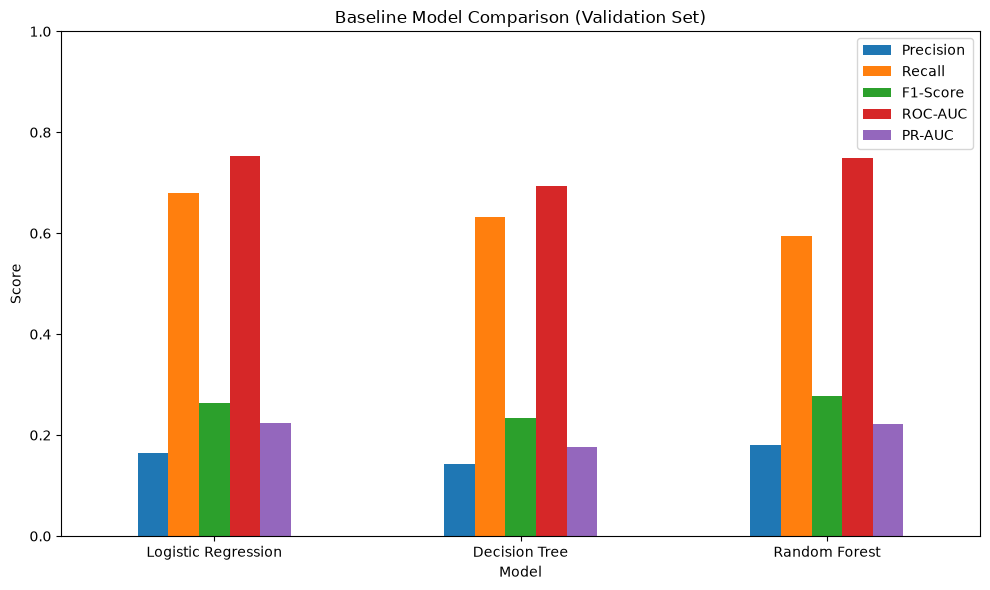

In [ ]:
plot_metrics = ["Precision", "Recall", "F1-Score", "ROC-AUC", "PR-AUC"]

ax = baseline_results.set_index("Model")[plot_metrics].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Baseline Model Comparison (Validation Set)")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


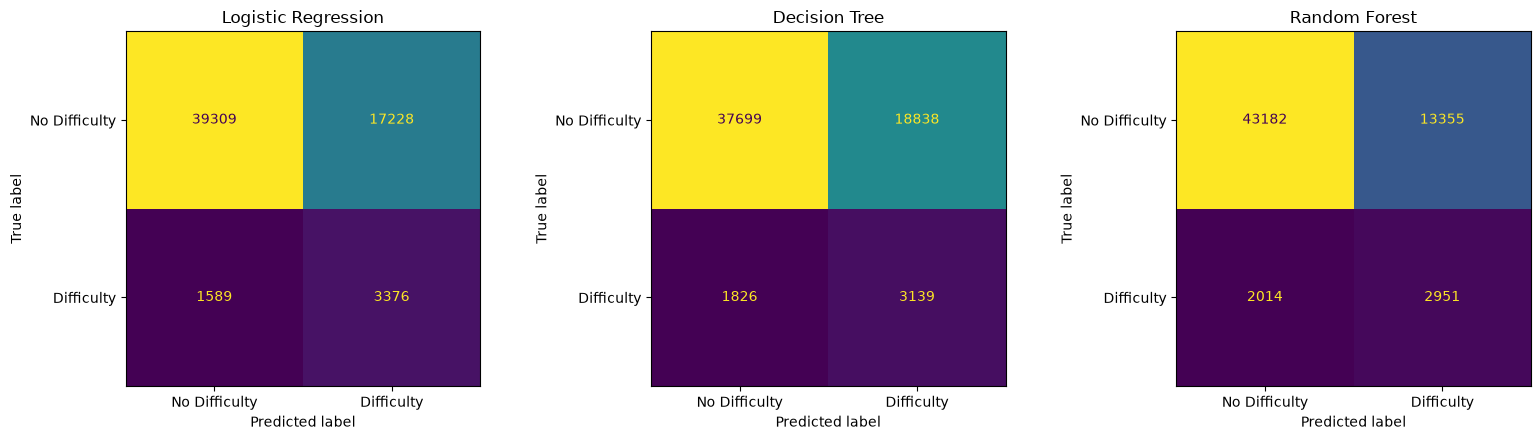

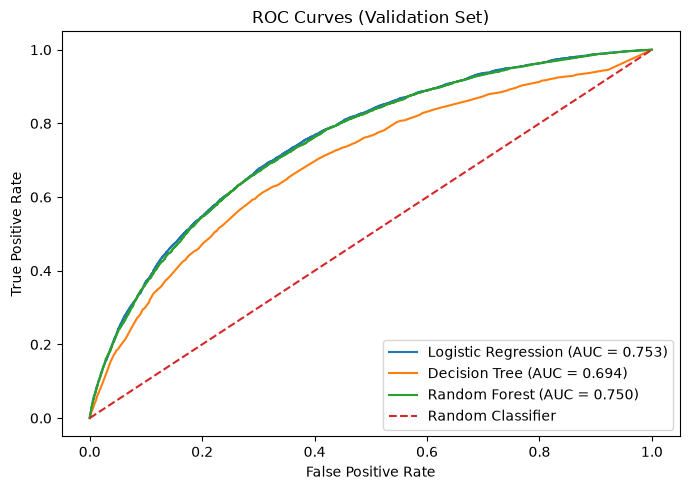

In [ ]:
# Confusion matrices and ROC curves for the three baseline models
baseline_models = [
    ("Logistic Regression", y_pred_logistic, y_prob_logistic),
    ("Decision Tree", y_pred_tree, y_prob_tree),
    ("Random Forest", y_pred_rf, y_prob_rf)
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (name, preds, _) in zip(axes, baseline_models):
    cm = confusion_matrix(y_val, preds)
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Difficulty", "Difficulty"]
    ).plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 5))

for name, _, probs in baseline_models:
    fpr, tpr, _ = roc_curve(y_val, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_val, probs):.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Validation Set)")
plt.legend()
plt.tight_layout()
plt.show()


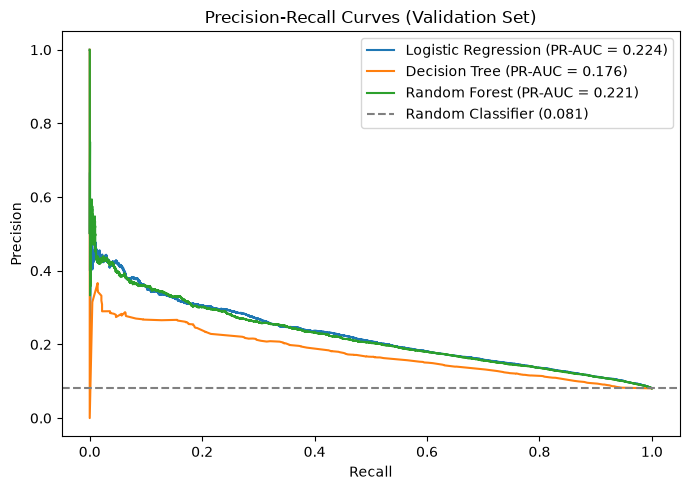

In [ ]:
plt.figure(figsize=(7, 5))

for name, _, probs in baseline_models:
    precision_curve, recall_curve, _ = precision_recall_curve(y_val, probs)
    plt.plot(
        recall_curve,
        precision_curve,
        label=f"{name} (PR-AUC = {average_precision_score(y_val, probs):.3f})"
    )

plt.axhline(
    y_val.mean(),
    linestyle="--",
    color="grey",
    label=f"Random Classifier ({y_val.mean():.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (Validation Set)")
plt.legend()
plt.tight_layout()
plt.show()


The precision-recall curves give a clearer picture than the ROC curves for this problem. The dashed line is the precision a random classifier would reach, which equals the positive rate in the validation set.

The comparison table above is used to decide which models are worth tuning.


## 18. Do the Historical Features Actually Help?

The project adds features from three historical sources: bureau records, previous applications, and installment payments. So far there is no evidence that they improve prediction, only that the model uses them.

Feature importance and SHAP cannot answer this question. They describe how a model uses the inputs it was given, not whether a different model trained without those inputs would do worse.

To test it directly, four models are trained with the same settings and the same split, and only the feature set changes:

- **A**: application features only
- **B**: application + bureau
- **C**: application + bureau + previous applications
- **D**: application + bureau + previous applications + installments (the full set)

A smaller Random Forest is used than the final model so that four fits stay reasonable in runtime. The point is the comparison between the four versions, not the absolute scores.


In [ ]:
bureau_cols = [c for c in X.columns if c.startswith("BUREAU_")]
prev_cols = [c for c in X.columns if c.startswith("PREV_")]
installment_cols = [c for c in X.columns if c.startswith("INSTALLMENT_")]

historical_cols = bureau_cols + prev_cols + installment_cols
application_cols = [c for c in X.columns if c not in historical_cols]

print("Application features       :", len(application_cols))
print("Bureau features            :", len(bureau_cols))
print("Previous application feats :", len(prev_cols))
print("Installment features       :", len(installment_cols))

feature_sets = {
    "A: Application only": application_cols,
    "B: + Bureau": application_cols + bureau_cols,
    "C: + Previous applications": application_cols + bureau_cols + prev_cols,
    "D: + Installments (full)": application_cols + bureau_cols + prev_cols + installment_cols
}


Application features       : 75
Bureau features            : 6
Previous application feats : 7
Installment features       : 8


In [ ]:
# This cell trains four Random Forests and takes a few minutes to run
ablation_results = []

for name, cols in feature_sets.items():
    numeric_subset = [c for c in numerical_features if c in cols]
    categorical_subset = [c for c in categorical_features if c in cols]

    ablation_pipeline = Pipeline(steps=[
        ("preprocessor", build_preprocessor(numeric_subset, categorical_subset)),
        ("model", RandomForestClassifier(
            n_estimators=100,
            max_depth=12,
            min_samples_split=20,
            min_samples_leaf=10,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])

    ablation_pipeline.fit(X_train[cols], y_train)

    probs = ablation_pipeline.predict_proba(X_val[cols])[:, 1]
    preds = (probs >= 0.50).astype(int)

    scores = evaluate_predictions(y_val, preds, probs, name)
    scores["Features"] = len(cols)
    ablation_results.append(scores)

    print(
        f"{name:<28} ROC-AUC {scores['ROC-AUC']:.4f}  "
        f"PR-AUC {scores['PR-AUC']:.4f}  F1 {scores['F1-Score']:.4f}"
    )


A: Application only          ROC-AUC 0.7378  PR-AUC 0.2093  F1 0.2623
B: + Bureau                  ROC-AUC 0.7403  PR-AUC 0.2117  F1 0.2658
C: + Previous applications   ROC-AUC 0.7432  PR-AUC 0.2148  F1 0.2701
D: + Installments (full)     ROC-AUC 0.7489  PR-AUC 0.2198  F1 0.2777


,Feature Set,Features,ROC-AUC,PR-AUC,F1-Score
0,A: Application only,75,0.7378,0.2093,0.2623
1,B: + Bureau,81,0.7403,0.2117,0.2658
2,C: + Previous applications,88,0.7432,0.2148,0.2701
3,D: + Installments (full),96,0.7489,0.2198,0.2777


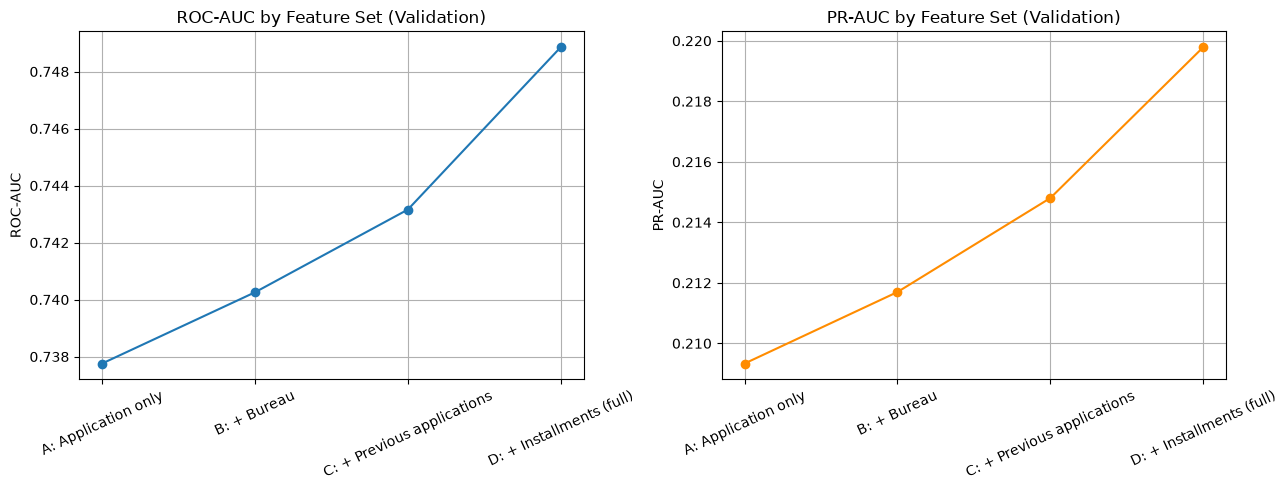

In [ ]:
ablation_df = pd.DataFrame(ablation_results)[
    ["Model", "Features", "ROC-AUC", "PR-AUC", "F1-Score"]
]

ablation_df = ablation_df.rename(columns={"Model": "Feature Set"})

display(ablation_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(ablation_df["Feature Set"], ablation_df["ROC-AUC"], marker="o")
axes[0].set_title("ROC-AUC by Feature Set (Validation)")
axes[0].set_ylabel("ROC-AUC")
axes[0].tick_params(axis="x", rotation=25)
axes[0].grid(True)

axes[1].plot(ablation_df["Feature Set"], ablation_df["PR-AUC"], marker="o",
             color="darkorange")
axes[1].set_title("PR-AUC by Feature Set (Validation)")
axes[1].set_ylabel("PR-AUC")
axes[1].tick_params(axis="x", rotation=25)
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# Change from the application-only baseline
baseline_row = ablation_df.iloc[0]

ablation_change = ablation_df.copy()
ablation_change["ROC-AUC change"] = (
    ablation_change["ROC-AUC"] - baseline_row["ROC-AUC"]
)
ablation_change["PR-AUC change"] = (
    ablation_change["PR-AUC"] - baseline_row["PR-AUC"]
)

display(
    ablation_change[
        ["Feature Set", "ROC-AUC change", "PR-AUC change"]
    ].round(4)
)


,Feature Set,ROC-AUC change,PR-AUC change
0,A: Application only,0.0000,0.0000
1,B: + Bureau,0.0025,0.0024
2,C: + Previous applications,0.0054,0.0055
3,D: + Installments (full),0.0111,0.0105


The table above shows how much each historical source changes performance compared with using application features alone.

This is a single validation split, so small differences should not be read as meaningful. A change of a few thousandths could easily come from the split itself rather than from the features. Larger and consistent gains across both ROC-AUC and PR-AUC are the ones worth trusting.

Whatever the result, this is the evidence the feature-engineering part of the project rests on, not the SHAP plots later.


## 19. Hyperparameter Tuning

Logistic Regression and Random Forest are tuned with cross-validation on the training data only. The validation set is kept out of the search so it stays usable for model selection and threshold choice.

ROC-AUC is used as the search metric because it does not depend on a threshold, which is chosen separately later.


In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

logistic_grid_search = GridSearchCV(
    estimator=LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    param_grid={"C": [0.01, 0.1, 1, 10]},
    scoring="roc_auc",
    cv=3,
    n_jobs=-1
)

logistic_grid_search.fit(X_train_processed, y_train)

print("Best parameters:", logistic_grid_search.best_params_)
print("Best CV ROC-AUC:", round(logistic_grid_search.best_score_, 4))

best_logistic_model = logistic_grid_search.best_estimator_

y_pred_logistic_tuned = best_logistic_model.predict(X_val_processed)
y_prob_logistic_tuned = best_logistic_model.predict_proba(X_val_processed)[:, 1]

logistic_tuned_scores = evaluate_predictions(
    y_val,
    y_pred_logistic_tuned,
    y_prob_logistic_tuned,
    "Logistic Regression (tuned)"
)

print("\nValidation performance:")
for metric, value in logistic_tuned_scores.items():
    if metric != "Model":
        print(f"{metric:<10}: {value:.4f}")


Best parameters: {'C': 0.01}
Best CV ROC-AUC: 0.7531

Validation performance:
Accuracy  : 0.6938
Precision : 0.1640
Recall    : 0.6814
F1-Score  : 0.2643
ROC-AUC   : 0.7530
PR-AUC    : 0.2244


In [ ]:
# This search trains several Random Forests and is the slowest cell in the notebook
rf_param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [8, 12, 16, 20],
    "min_samples_split": [10, 20, 30],
    "min_samples_leaf": [5, 10, 20]
}

rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    param_distributions=rf_param_dist,
    n_iter=8,
    scoring="roc_auc",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

rf_random_search.fit(X_train_processed, y_train)

print("Best parameters:", rf_random_search.best_params_)
print("Best CV ROC-AUC:", round(rf_random_search.best_score_, 4))

best_rf_model = rf_random_search.best_estimator_

y_pred_rf_tuned = best_rf_model.predict(X_val_processed)
y_prob_rf_tuned = best_rf_model.predict_proba(X_val_processed)[:, 1]

rf_tuned_scores = evaluate_predictions(
    y_val,
    y_pred_rf_tuned,
    y_prob_rf_tuned,
    "Random Forest (tuned)"
)

print("\nValidation performance:")
for metric, value in rf_tuned_scores.items():
    if metric != "Model":
        print(f"{metric:<10}: {value:.4f}")


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_depth': 20}
Best CV ROC-AUC: 0.7569

Validation performance:
Accuracy  : 0.8653
Precision : 0.2536
Recall    : 0.3440
F1-Score  : 0.2920
ROC-AUC   : 0.7558
PR-AUC    : 0.2261


## 20. Final Model Selection

All five versions are compared on the validation set. The model with the best validation ROC-AUC and PR-AUC is selected as the final model.

ROC-AUC and PR-AUC are used for this decision rather than F1, because F1 at the default 0.50 threshold depends on a threshold that has not been chosen yet.


In [ ]:
all_validation_results = pd.DataFrame([
    logistic_scores,
    tree_scores,
    rf_scores,
    logistic_tuned_scores,
    rf_tuned_scores
])

all_validation_results = all_validation_results.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(all_validation_results.round(4))


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Random Forest (tuned),0.8653,0.2536,0.3440,0.2920,0.7558,0.2261
1,Logistic Regression (tuned),0.6938,0.1640,0.6814,0.2643,0.7530,0.2244
2,Logistic Regression,0.6940,0.1639,0.6800,0.2641,0.7530,0.2237
3,Random Forest,0.7501,0.1810,0.5944,0.2775,0.7499,0.2214
4,Decision Tree,0.6640,0.1428,0.6322,0.2330,0.6936,0.1756


In [ ]:
candidate_models = {
    "Logistic Regression": (logistic_model, y_prob_logistic),
    "Decision Tree": (decision_tree_model, y_prob_tree),
    "Random Forest": (random_forest_model, y_prob_rf),
    "Logistic Regression (tuned)": (best_logistic_model, y_prob_logistic_tuned),
    "Random Forest (tuned)": (best_rf_model, y_prob_rf_tuned)
}

best_model_name = all_validation_results.iloc[0]["Model"]
final_model, y_prob_val_final = candidate_models[best_model_name]

print("Selected model:", best_model_name)
print("Validation ROC-AUC:", round(all_validation_results.iloc[0]["ROC-AUC"], 4))
print("Validation PR-AUC :", round(all_validation_results.iloc[0]["PR-AUC"], 4))


Selected model: Random Forest (tuned)
Validation ROC-AUC: 0.7558
Validation PR-AUC : 0.2261


The selected model is stored in `final_model` and its validation probabilities in `y_prob_val_final`. Everything after this point uses those two variables, so the notebook stays consistent even if a different model wins the comparison on a re-run.


## 21. Threshold Selection

A classifier returns a probability. Turning it into a decision needs a cut-off, and 0.50 is only a default, not a good choice by itself.

The threshold is selected on the **validation set** and then frozen. It is not re-tuned on the test set later. Choosing the threshold on the test set would make the reported test metrics look better than the model really is.

The table below shows precision, recall, F1, and the raw count of false positives and false negatives at each threshold, because the counts make the trade-off easier to read than the rates alone:

- A **false positive** is a lower-risk applicant flagged as risky. In a real process this could mean a rejected application or extra checks for someone who would have repaid.
- A **false negative** is a risky applicant classified as low risk, which is the case a lender usually cares about most.

There is no real cost data for this project, so the threshold is chosen on model performance only. F1 is used because it balances precision and recall and needs no cost assumptions, not because it is the right business objective. A lender with real numbers for the cost of each error type would likely choose a different point on this table.


In [ ]:
thresholds_to_test = np.arange(0.20, 0.75, 0.05)

threshold_rows = []

for threshold in thresholds_to_test:
    preds = (y_prob_val_final >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, preds).ravel()

    threshold_rows.append({
        "Threshold": round(threshold, 2),
        "Precision": precision_score(y_val, preds, zero_division=0),
        "Recall": recall_score(y_val, preds, zero_division=0),
        "F1-Score": f1_score(y_val, preds, zero_division=0),
        "False Positives": fp,
        "False Negatives": fn,
        "Flagged as risky": tp + fp
    })

threshold_df = pd.DataFrame(threshold_rows)

display(threshold_df.round(4))


,Threshold,Precision,Recall,F1-Score,False Positives,False Negatives,Flagged as risky
0,0.20,0.1027,0.9412,0.1852,40823,292,45496
1,0.25,0.1205,0.8796,0.2120,31875,598,36242
2,0.30,0.1410,0.7887,0.2393,23854,1049,27770
3,0.35,0.1642,0.6802,0.2645,17194,1588,20571
4,0.40,0.1922,0.5736,0.2879,11973,2117,14821
5,0.45,0.2210,0.4602,0.2986,8053,2680,10338
6,0.50,0.2536,0.3440,0.2920,5027,3257,6735
7,0.55,0.2913,0.2431,0.2650,2937,3758,4144
8,0.60,0.3258,0.1511,0.2064,1552,4215,2302
9,0.65,0.3735,0.0868,0.1409,723,4534,1154


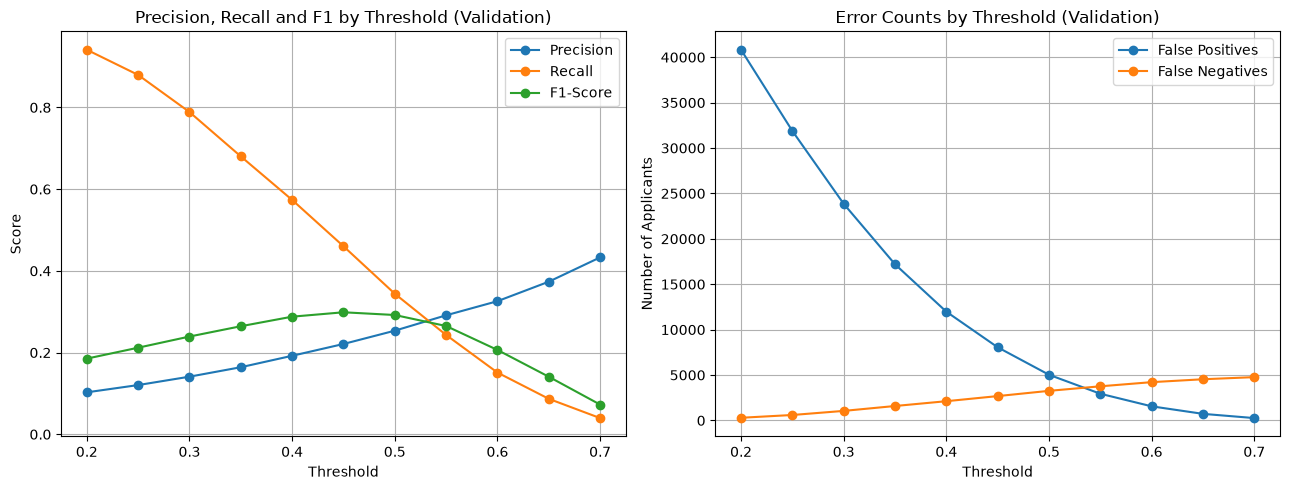

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(threshold_df["Threshold"], threshold_df["Precision"],
             marker="o", label="Precision")
axes[0].plot(threshold_df["Threshold"], threshold_df["Recall"],
             marker="o", label="Recall")
axes[0].plot(threshold_df["Threshold"], threshold_df["F1-Score"],
             marker="o", label="F1-Score")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Precision, Recall and F1 by Threshold (Validation)")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(threshold_df["Threshold"], threshold_df["False Positives"],
             marker="o", label="False Positives")
axes[1].plot(threshold_df["Threshold"], threshold_df["False Negatives"],
             marker="o", label="False Negatives")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Number of Applicants")
axes[1].set_title("Error Counts by Threshold (Validation)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [ ]:
best_row = threshold_df.loc[threshold_df["F1-Score"].idxmax()]

FINAL_THRESHOLD = float(best_row["Threshold"])

print("Selected threshold:", FINAL_THRESHOLD)
print("Validation precision:", round(best_row["Precision"], 4))
print("Validation recall   :", round(best_row["Recall"], 4))
print("Validation F1-Score :", round(best_row["F1-Score"], 4))
print("Validation false positives:", int(best_row["False Positives"]))
print("Validation false negatives:", int(best_row["False Negatives"]))

print("\nThreshold is now frozen and will not be changed again.")


Selected threshold: 0.45
Validation precision: 0.221
Validation recall   : 0.4602
Validation F1-Score : 0.2986
Validation false positives: 8053
Validation false negatives: 2680

Threshold is now frozen and will not be changed again.


The two lines in the right-hand chart move in opposite directions, which is the whole point of the threshold decision. Lowering it catches more risky applicants but flags many more people who would have repaid; raising it does the reverse.

The value in `FINAL_THRESHOLD` is used for every prediction from here on, including the test evaluation and the saved model.


## 22. Final Evaluation on the Test Set

The test set is used here for the first and only time.

The selected model and the frozen threshold are applied to it without any further adjustment. These are the numbers that describe how the model is expected to behave on applicants it has never seen.


In [ ]:
y_prob_test = final_model.predict_proba(X_test_processed)[:, 1]
y_pred_test = (y_prob_test >= FINAL_THRESHOLD).astype(int)

final_test_scores = evaluate_predictions(
    y_test,
    y_pred_test,
    y_prob_test,
    f"{best_model_name} @ threshold {FINAL_THRESHOLD}"
)

final_results_df = pd.DataFrame([final_test_scores])

print("FINAL TEST RESULTS")
print("------------------")
for metric, value in final_test_scores.items():
    if metric != "Model":
        print(f"{metric:<10}: {value:.4f}")

print("\nFor reference, a model predicting the majority class for everyone")
print("would reach an accuracy of", round(1 - y_test.mean(), 4),
      "and a recall of 0.")

display(final_results_df.round(4))


FINAL TEST RESULTS
------------------
Accuracy  : 0.8312
Precision : 0.2279
Recall    : 0.4570
F1-Score  : 0.3042
ROC-AUC   : 0.7611
PR-AUC    : 0.2398

For reference, a model predicting the majority class for everyone
would reach an accuracy of 0.9193 and a recall of 0.


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Random Forest (tuned) @ threshold 0.45,0.8312,0.2279,0.457,0.3042,0.7611,0.2398


In [ ]:
print(classification_report(
    y_test,
    y_pred_test,
    target_names=["No Difficulty", "Payment Difficulty"],
    digits=4
))

cm_final = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm_final.ravel()

print("True negatives :", tn)
print("False positives:", fp)
print("False negatives:", fn)
print("True positives :", tp)


                    precision    recall  f1-score   support

     No Difficulty     0.9477    0.8641    0.9040     56538
Payment Difficulty     0.2279    0.4570    0.3042      4965

          accuracy                         0.8312     61503
         macro avg     0.5878    0.6605    0.6041     61503
      weighted avg     0.8896    0.8312    0.8555     61503

True negatives : 48853
False positives: 7685
False negatives: 2696
True positives : 2269


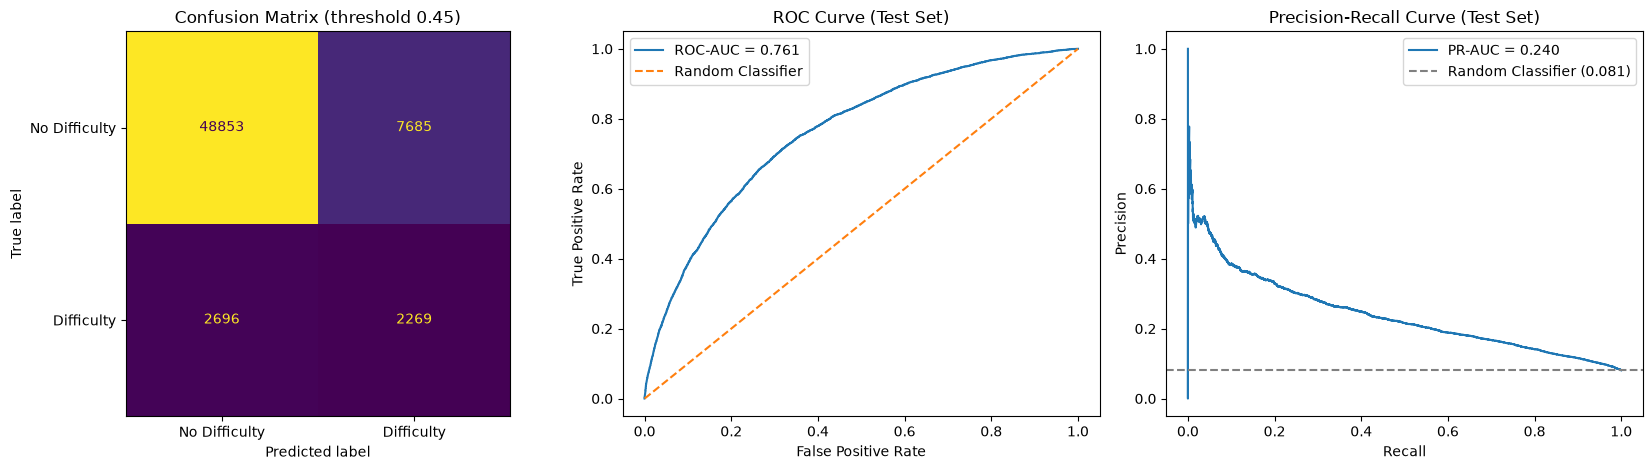

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=["No Difficulty", "Difficulty"]
).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f"Confusion Matrix (threshold {FINAL_THRESHOLD})")

fpr_final, tpr_final, _ = roc_curve(y_test, y_prob_test)
axes[1].plot(
    fpr_final,
    tpr_final,
    label=f"ROC-AUC = {final_test_scores['ROC-AUC']:.3f}"
)
axes[1].plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve (Test Set)")
axes[1].legend()

precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob_test)
axes[2].plot(
    recall_curve,
    precision_curve,
    label=f"PR-AUC = {final_test_scores['PR-AUC']:.3f}"
)
axes[2].axhline(
    y_test.mean(),
    linestyle="--",
    color="grey",
    label=f"Random Classifier ({y_test.mean():.3f})"
)
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve (Test Set)")
axes[2].legend()

plt.tight_layout()
plt.show()


Precision on the positive class stays low. That is expected on this dataset: with an 8% base rate and no strong individual predictor, a model that catches a useful share of risky applicants will also flag a large number of applicants who would have repaid.

The comparison that matters is with the base rate. Precision above 8% means the flagged group is genuinely riskier than a randomly chosen group of applicants, and PR-AUC above 0.08 means the ranking carries real information.


## 23. Explainability with SHAP

A credit decision needs an explanation, so SHAP is used to look at the model from two angles.

**Global explanation** answers which features the model relies on most across applicants. **Individual explanation** answers why one specific applicant received a higher or lower predicted risk.

One thing SHAP does not do is prove that a feature improves performance, or that it causes anything. It describes how this trained model uses its inputs. The question of whether the historical features help was answered separately in the ablation experiment.

Because one-hot encoding changes the column names, the processed feature names are taken from the preprocessor so the SHAP output can be matched back to the original features. SHAP is also run on a sample of the test set rather than all rows, for runtime reasons.


In [ ]:
import shap

feature_names = preprocessor.get_feature_names_out()

print("Processed feature count:", len(feature_names))

# TreeExplainer only works with tree-based models
if isinstance(final_model, (RandomForestClassifier, DecisionTreeClassifier)):
    shap_model = final_model
    shap_model_name = best_model_name
else:
    shap_model = best_rf_model
    shap_model_name = "Random Forest (tuned)"
    print(
        "The selected model is not tree-based, so SHAP is run on the tuned "
        "Random Forest instead. The explanations below describe that model."
    )

print("SHAP model:", shap_model_name)


Processed feature count: 212
SHAP model: Random Forest (tuned)


c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
rng = np.random.RandomState(RANDOM_STATE)
sample_size = 300

sample_idx = rng.choice(
    X_test_processed.shape[0],
    size=sample_size,
    replace=False
)

X_test_sample = X_test_processed[sample_idx]

# One-hot encoding can produce a sparse matrix, and SHAP needs a dense array
if hasattr(X_test_sample, "toarray"):
    X_test_sample = X_test_sample.toarray()

explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_test_sample, check_additivity=False)

# Depending on the SHAP version, the output is either a list per class
# or a single array with the class on the last axis
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
else:
    shap_values_class1 = shap_values[:, :, 1]

print("SHAP values shape for the risk class:", shap_values_class1.shape)


SHAP values shape for the risk class: (300, 212)


### Global Explanation

The summary plot shows the size and direction of each feature's effect: whether high or low values of a feature push a prediction toward higher risk.


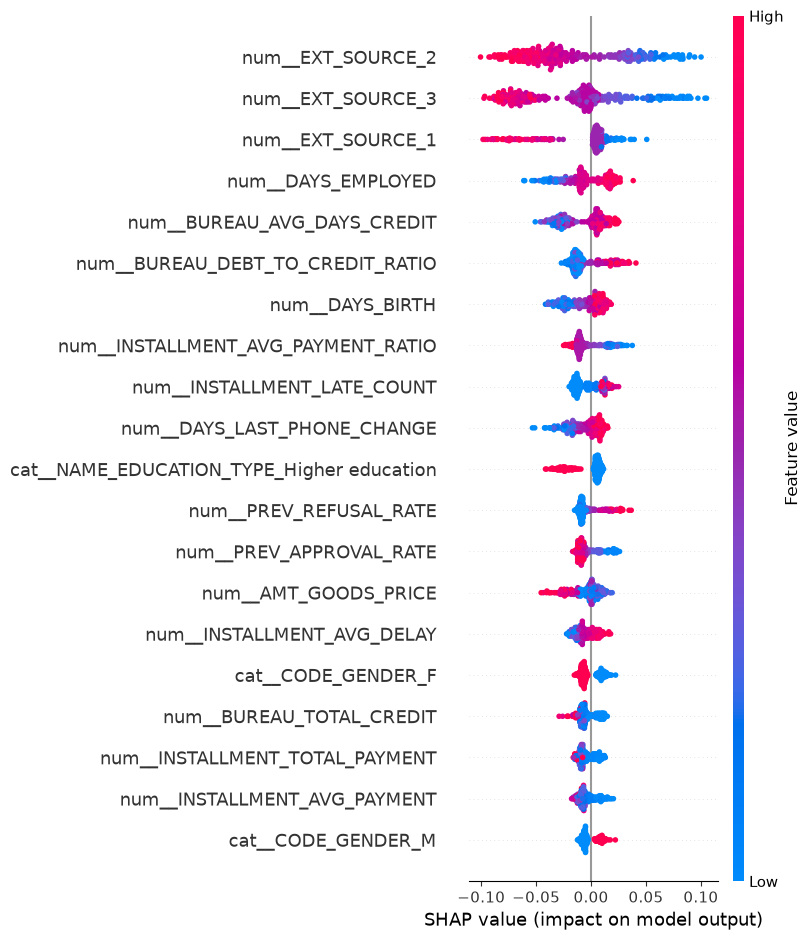

In [ ]:
shap.summary_plot(
    shap_values_class1,
    X_test_sample,
    feature_names=feature_names,
    show=True
)


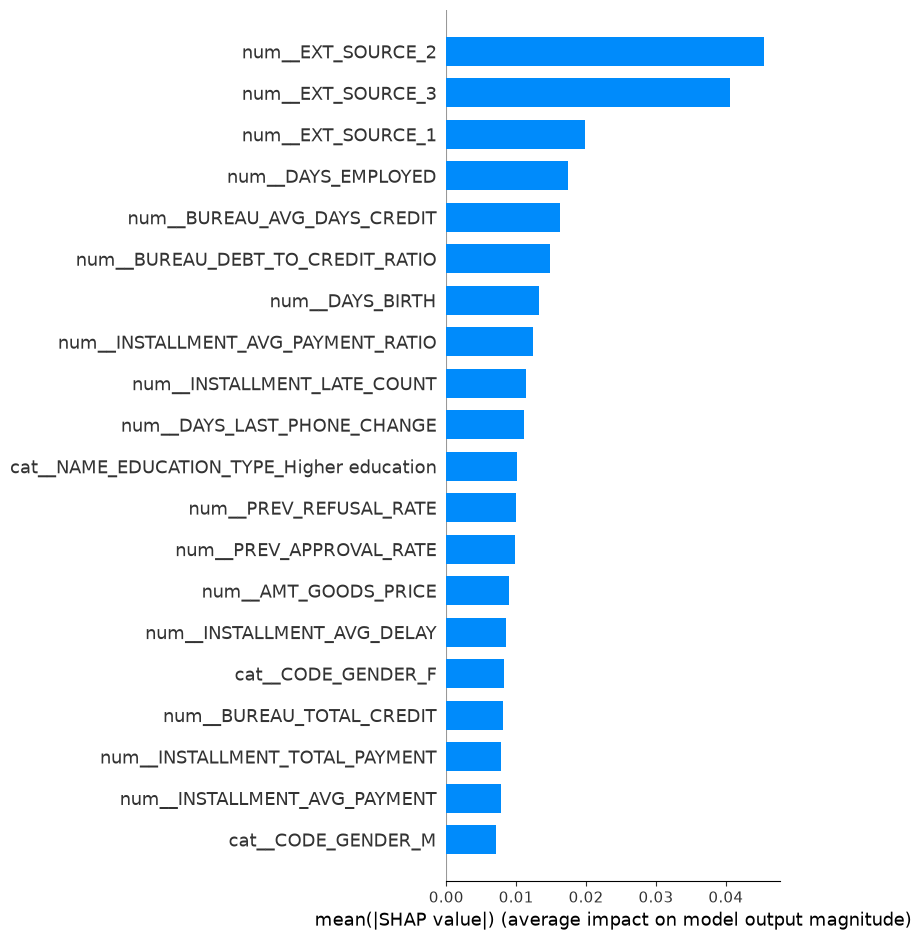

In [ ]:
shap.summary_plot(
    shap_values_class1,
    X_test_sample,
    feature_names=feature_names,
    plot_type="bar",
    show=True
)


In [ ]:
# Same ranking as the bar chart, in table form
mean_abs_shap = np.abs(shap_values_class1).mean(axis=0)

shap_ranking = pd.DataFrame({
    "Feature": feature_names,
    "Mean |SHAP|": mean_abs_shap
}).sort_values("Mean |SHAP|", ascending=False).reset_index(drop=True)

top_features = shap_ranking.head(15)
display(top_features)

# How many of the top 15 come from the engineered historical sources
historical_prefixes = ("num__BUREAU_", "num__PREV_", "num__INSTALLMENT_")

historical_in_top = top_features[
    top_features["Feature"].str.startswith(historical_prefixes)
]

print(
    "Engineered historical features in the top 15:",
    len(historical_in_top)
)
print(historical_in_top["Feature"].tolist())


,Feature,Mean |SHAP|
0,num__EXT_SOURCE_2,0.045462
1,num__EXT_SOURCE_3,0.040644
2,num__EXT_SOURCE_1,0.019815
3,num__DAYS_EMPLOYED,0.017410
4,num__BUREAU_AVG_DAYS_CREDIT,0.016215
5,num__BUREAU_DEBT_TO_CREDIT_RATIO,0.014834
6,num__DAYS_BIRTH,0.013271
7,num__INSTALLMENT_AVG_PAYMENT_RATIO,0.012430
8,num__INSTALLMENT_LATE_COUNT,0.011410
9,num__DAYS_LAST_PHONE_CHANGE,0.011120


Engineered historical features in the top 15: 7
['num__BUREAU_AVG_DAYS_CREDIT', 'num__BUREAU_DEBT_TO_CREDIT_RATIO', 'num__INSTALLMENT_AVG_PAYMENT_RATIO', 'num__INSTALLMENT_LATE_COUNT', 'num__PREV_REFUSAL_RATE', 'num__PREV_APPROVAL_RATE', 'num__INSTALLMENT_AVG_DELAY']


The table above lists the features with the largest average effect on the model's risk output, and the count below it shows how many of them come from the bureau, previous-application, and installment sources built earlier in the notebook.

This says the model leans on those engineered features when making predictions. Whether they improve predictive performance is a separate question, answered by the ablation results in section 18.


### Individual Explanation

The same values can explain a single applicant. One high-risk applicant from the sample is used as an example, showing which features pushed the prediction up and which pushed it down.

These are the features with the strongest influence on the model's prediction for this applicant. They are not reasons the applicant will default.


In [ ]:
# Pick the applicant in the sample with the highest predicted risk
sample_probs = shap_model.predict_proba(X_test_sample)[:, 1]
example_position = int(np.argmax(sample_probs))

example_prob = sample_probs[example_position]
example_shap = shap_values_class1[example_position]

print("Predicted risk probability:", round(float(example_prob), 4))
print("Decision threshold        :", FINAL_THRESHOLD)
print(
    "Model decision            :",
    "Flagged as risky" if example_prob >= FINAL_THRESHOLD else "Not flagged"
)

example_df = pd.DataFrame({
    "Feature": feature_names,
    "Feature value (scaled)": X_test_sample[example_position],
    "SHAP value": example_shap
})

increasing = example_df.sort_values(
    "SHAP value", ascending=False
).head(5)

decreasing = example_df.sort_values(
    "SHAP value", ascending=True
).head(5)

print("\nFeatures pushing this prediction toward higher risk:")
display(increasing.round(4))

print("Features pushing this prediction toward lower risk:")
display(decreasing.round(4))


Predicted risk probability: 0.749
Decision threshold        : 0.45
Model decision            : Flagged as risky

Features pushing this prediction toward higher risk:


,Feature,Feature value (scaled),SHAP value
28,num__EXT_SOURCE_2,-2.3848,0.0789
73,num__PREV_REFUSAL_RATE,3.1047,0.0266
27,num__EXT_SOURCE_1,-2.3854,0.0226
72,num__PREV_APPROVAL_RATE,-1.6366,0.0212
7,num__DAYS_EMPLOYED,0.7961,0.0208


Features pushing this prediction toward lower risk:


,Feature,Feature value (scaled),SHAP value
74,num__BUREAU_DEBT_TO_CREDIT_RATIO,-0.2425,-0.0166
63,num__BUREAU_TOTAL_CREDIT,-0.2582,-0.0104
62,num__BUREAU_CREDIT_COUNT,0.2743,-0.0096
81,num__INSTALLMENT_AVG_PAYMENT_RATIO,-0.0116,-0.0080
79,num__INSTALLMENT_AVG_DELAY,-0.1946,-0.0080


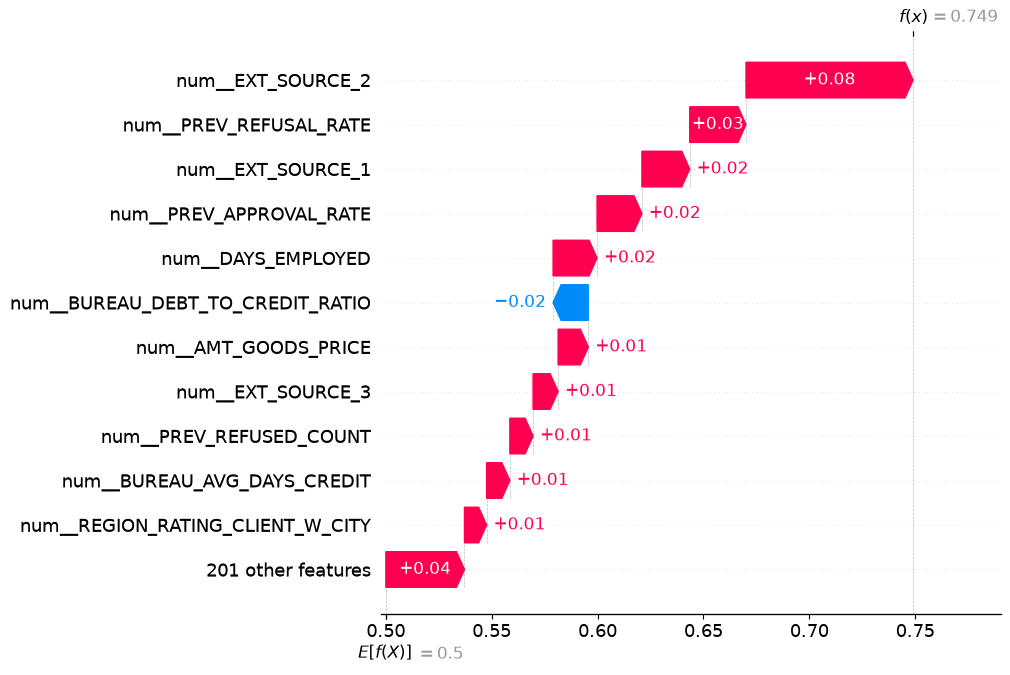

Average predicted risk for the sample: 0.5


In [ ]:
# Waterfall view of the same applicant.
# The waterfall helper moved between SHAP versions, so a bar chart is used
# as a fallback if it is not available.
base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = base_value[1]

try:
    shap.plots._waterfall.waterfall_legacy(
        base_value,
        example_shap,
        feature_names=list(feature_names),
        max_display=12
    )
except Exception:
    top_contributions = example_df.reindex(
        example_df["SHAP value"].abs().sort_values(ascending=False).index
    ).head(12).iloc[::-1]

    plt.figure(figsize=(8, 6))
    colors = ["tab:red" if v > 0 else "tab:blue"
              for v in top_contributions["SHAP value"]]
    plt.barh(
        top_contributions["Feature"],
        top_contributions["SHAP value"],
        color=colors
    )
    plt.axvline(0, color="black", linewidth=0.8)
    plt.xlabel("SHAP value (effect on predicted risk)")
    plt.title("Strongest Influences on This Applicant's Prediction")
    plt.tight_layout()
    plt.show()

print("Average predicted risk for the sample:", round(float(base_value), 4))


The plot starts at the average prediction for the sample and shows how each feature moves this applicant away from it.

This kind of output is what makes the model usable in a setting where a decision has to be explained to the applicant, rather than only scored.


## 24. Saving the Final Pipeline

To be useful outside the notebook, the model has to be saved together with its preprocessing. Saving only the classifier would mean rebuilding the imputation, scaling, and encoding by hand somewhere else, which is exactly where mistakes happen.

The fitted preprocessor and the fitted model are combined into a single `Pipeline` object and saved with joblib. The decision threshold and the risk bands are saved next to it, because they are part of how the model is meant to be used.

The saved pipeline is checked against the test predictions produced above to confirm it behaves identically.


In [ ]:
import joblib
from sklearn.pipeline import Pipeline as SklearnPipeline

# Both steps are already fitted on the training data
final_pipeline = SklearnPipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", final_model)
])

# Check the pipeline reproduces the predictions made earlier
pipeline_probs = final_pipeline.predict_proba(X_test)[:, 1]

print(
    "Pipeline matches the earlier test predictions:",
    np.allclose(pipeline_probs, y_prob_test)
)


Pipeline matches the earlier test predictions: True


### Risk Categories

The predicted probability is easier to use if it is turned into a simple category.

These bands are defined for this project, not taken from any banking standard. The High Risk boundary is the decision threshold selected on the validation set. The Low/Medium boundary is the median predicted probability on the validation set, so roughly half of applicants fall into the Low Risk band.


In [ ]:
MEDIUM_RISK_CUTOFF = float(np.round(np.median(y_prob_val_final), 3))
HIGH_RISK_CUTOFF = FINAL_THRESHOLD

RISK_BANDS = {
    "medium_cutoff": MEDIUM_RISK_CUTOFF,
    "high_cutoff": HIGH_RISK_CUTOFF
}

print("Low Risk    : probability below", MEDIUM_RISK_CUTOFF)
print("Medium Risk :", MEDIUM_RISK_CUTOFF, "to", HIGH_RISK_CUTOFF)
print("High Risk   : probability of", HIGH_RISK_CUTOFF, "or above")


def risk_category(probability, bands=RISK_BANDS):
    """Convert a predicted probability into a project-defined risk band."""
    if probability >= bands["high_cutoff"]:
        return "High Risk"
    if probability >= bands["medium_cutoff"]:
        return "Medium Risk"
    return "Low Risk"


# Actual target rate inside each band on the test set
band_check = pd.DataFrame({
    "Risk category": [risk_category(p) for p in y_prob_test],
    "TARGET": y_test.values
})

band_summary = band_check.groupby("Risk category").agg(
    applicants=("TARGET", "size"),
    actual_difficulty_rate=("TARGET", "mean")
)

display(band_summary.round(4))


Low Risk    : probability below 0.281
Medium Risk : 0.281 to 0.45
High Risk   : probability of 0.45 or above


,applicants,actual_difficulty_rate
Risk category,,
High Risk,9954,0.2279
Low Risk,30884,0.0282
Medium Risk,20665,0.0883


The table shows the actual repayment-difficulty rate inside each band on the test set, which is the honest way to describe what the bands mean: they separate applicants by observed risk level, they do not predict individual outcomes.


In [ ]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)

pipeline_path = MODELS_DIR / "credit_risk_pipeline.joblib"
metadata_path = MODELS_DIR / "model_metadata.joblib"

joblib.dump(final_pipeline, pipeline_path)

# A reference row of typical values, used by the app to fill in fields
# the user is not asked about
template_row = {}
for col in X_train.columns:
    if col in numerical_features:
        template_row[col] = float(X_train[col].median())
    else:
        template_row[col] = X_train[col].mode().iloc[0]

metadata = {
    "model_name": best_model_name,
    "threshold": FINAL_THRESHOLD,
    "risk_bands": RISK_BANDS,
    "feature_order": list(X_train.columns),
    "numerical_features": numerical_features,
    "categorical_features": categorical_features,
    "template_row": template_row,
    "test_metrics": final_test_scores
}

joblib.dump(metadata, metadata_path)

print("Pipeline saved to:", pipeline_path)
print("Metadata saved to:", metadata_path)


Pipeline saved to: C:\Credit-Risk-Scoring-System\models\credit_risk_pipeline.joblib
Metadata saved to: C:\Credit-Risk-Scoring-System\models\model_metadata.joblib


## 25. Prediction Function

A small helper wraps the saved pipeline so a new applicant can be scored in one call. The same function lives in `src/predict.py` and is what the Streamlit app uses, so the app and the notebook cannot drift apart.

It takes applicant data as a DataFrame, applies the same infinite-value handling used during training, runs the saved pipeline, and returns the probability, the decision at the frozen threshold, and the risk band.


In [ ]:
def predict_credit_risk(applicant_data, pipeline=None, meta=None):
    """Score one or more applicants with the saved pipeline."""
    pipeline = pipeline if pipeline is not None else final_pipeline
    meta = meta if meta is not None else metadata

    if isinstance(applicant_data, dict):
        applicant_data = pd.DataFrame([applicant_data])

    missing_cols = set(meta["feature_order"]) - set(applicant_data.columns)
    if missing_cols:
        raise ValueError(
            f"Missing {len(missing_cols)} required columns, "
            f"for example: {sorted(missing_cols)[:5]}"
        )

    data = applicant_data[meta["feature_order"]].copy()
    data = data.replace([np.inf, -np.inf], np.nan)

    probabilities = pipeline.predict_proba(data)[:, 1]
    threshold = meta["threshold"]

    return pd.DataFrame({
        "risk_probability": probabilities.round(4),
        "flagged_as_risky": (probabilities >= threshold).astype(int),
        "risk_category": [
            risk_category(p, meta["risk_bands"]) for p in probabilities
        ]
    })


In [ ]:
# Check the helper on a few real applicants from the test set
loaded_pipeline = joblib.load(pipeline_path)
loaded_metadata = joblib.load(metadata_path)

example_applicants = X_test.head(5)

predictions = predict_credit_risk(
    example_applicants,
    pipeline=loaded_pipeline,
    meta=loaded_metadata
)

predictions["actual_target"] = y_test.head(5).values

display(predictions)


,risk_probability,flagged_as_risky,risk_category,actual_target
0,0.2417,0,Low Risk,0
1,0.2756,0,Low Risk,0
2,0.5407,1,High Risk,0
3,0.2803,0,Low Risk,0
4,0.4200,0,Medium Risk,0


The pipeline reloaded from disk produces predictions without any manual preprocessing, which is what makes it usable in the Streamlit app under `app/`.


## 26. Conclusion

The summary below collects the final numbers in one place so they do not have to be read back from earlier sections.


In [ ]:
print("PROJECT SUMMARY")
print("=" * 50)

print("Applicants in dataset :", len(df_model))
print("Features used         :", X.shape[1])
print("Train / Val / Test    :",
      len(X_train), "/", len(X_val), "/", len(X_test))
print("Positive class rate   :", round(y.mean(), 4))

print("\nSelected model        :", best_model_name)
print("Decision threshold    :", FINAL_THRESHOLD)

print("\nFinal test performance:")
for metric in ["Accuracy", "Precision", "Recall", "F1-Score",
               "ROC-AUC", "PR-AUC"]:
    print(f"  {metric:<10}: {final_test_scores[metric]:.4f}")

print("\nAblation (validation ROC-AUC by feature set):")
for _, row in ablation_df.iterrows():
    print(f"  {row['Feature Set']:<28} {row['ROC-AUC']:.4f}"
          f"   PR-AUC {row['PR-AUC']:.4f}")

print("\nTop 5 features by mean |SHAP|:")
for _, row in shap_ranking.head(5).iterrows():
    print(f"  {row['Feature']:<40} {row['Mean |SHAP|']:.5f}")


PROJECT SUMMARY
Applicants in dataset : 307511
Features used         : 96
Train / Val / Test    : 184506 / 61502 / 61503
Positive class rate   : 0.0807

Selected model        : Random Forest (tuned)
Decision threshold    : 0.45

Final test performance:
  Accuracy  : 0.8312
  Precision : 0.2279
  Recall    : 0.4570
  F1-Score  : 0.3042
  ROC-AUC   : 0.7611
  PR-AUC    : 0.2398

Ablation (validation ROC-AUC by feature set):
  A: Application only          0.7378   PR-AUC 0.2093
  B: + Bureau                  0.7403   PR-AUC 0.2117
  C: + Previous applications   0.7432   PR-AUC 0.2148
  D: + Installments (full)     0.7489   PR-AUC 0.2198

Top 5 features by mean |SHAP|:
  num__EXT_SOURCE_2                        0.04546
  num__EXT_SOURCE_3                        0.04064
  num__EXT_SOURCE_1                        0.01981
  num__DAYS_EMPLOYED                       0.01741
  num__BUREAU_AVG_DAYS_CREDIT              0.01622


This project built a credit risk scoring model on the Home Credit application data, extended with applicant-level features from three historical sources: bureau credit records, previous applications with the lender, and installment payment history.

Logistic Regression, Decision Tree, and Random Forest were trained on the same data and compared on a validation set using ROC-AUC and PR-AUC rather than accuracy, since about 8% of applicants belong to the positive class and accuracy is uninformative at that rate. Two of the models were then tuned with cross-validation on the training data, and the best version by validation ROC-AUC was selected as the final model. The numbers for that model are printed above.

The decision threshold was chosen on the validation set by looking at precision, recall, F1, and the resulting false positive and false negative counts, then frozen before the test set was used. The test set was scored once with that fixed threshold.

Two checks support the feature-engineering part of the project. The ablation experiment compares models trained with and without each historical source, which is direct evidence about whether those features help. The SHAP analysis shows which features the model relies on, including how many of the engineered historical features appear in the top ranks, but it describes model behaviour rather than proving predictive value.

Precision on the risky class stays low in absolute terms. This is what this dataset supports, and the honest way to read the result is against the 8% base rate: the flagged group is measurably riskier than a random group of applicants. The model is useful for ranking and prioritising applications, not for making an automatic accept or reject decision.

The final pipeline, including preprocessing, is saved with joblib and used by a small Streamlit app so the model can score new applicants outside the notebook.


## 27. Limitations

- The files from the same Kaggle dataset (`POS_CASH_balance.csv`, `credit_card_balance.csv`) were not used, so the model has no monthly balance history or credit card behaviour. These could be added in a later version.
- There is no real cost data for a wrong decision, so the threshold was chosen on model performance alone. A lender with actual costs for false positives and false negatives would probably choose a different threshold from the same table.
- The results come from a single random split. A repeated or cross-validated evaluation would give a better idea of how much the numbers move between splits, which matters for the smaller differences in the ablation table.
- The model was validated only on this dataset. There is no test on data from a different time period or a different lender, so nothing here says how it would hold up as applicant behaviour changes.
- The final model is trained on the training portion only, not on training plus validation. This keeps the threshold and the model consistent with each other, but it does leave some data unused.
- SHAP values were computed on a sample of 300 test rows for runtime reasons. The overall ranking should be stable, but individual values would shift on a larger sample.
- Some cleaning decisions, such as the missing-value cut-off used to drop the property columns, were based on manual review rather than a systematic feature selection method.
- The historical features are aggregates over an applicant's whole history. They do not capture whether the behaviour is recent or old, which is usually important in credit risk.


## 28. Future Improvements

- Add the remaining Home Credit tables to capture monthly balance and credit card behaviour.

- Add time-aware versions of the historical features, for example payment behaviour over the last 12 months separately from the full history.

- Replace the single split with repeated or cross-validated evaluation so the differences in the ablation table can be judged against their variation.

- Test a gradient boosting model and compare it with the current models using the same validation setup.

- Revisit the threshold with real cost assumptions if they become available, since the current choice is a modelling decision rather than a business one.